# Projet *Getaround Analysis* – Certification CDSD – bloc 5

<br>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Getaround_%28Europe%29.png/960px-Getaround_%28Europe%29.png" alt="Getaround logo" width="400">
<br>

Auteur : Yoann ROBERT

Date de la présentation : 16 juin 2026

---

## Introduction

### Contexte

### Dataset

### Objectifs

### Indications

### Livrable

### Plan de l'étude


## Introduction

### Contexte

Getaround est l'équivalent d'Airbnb pour les voitures : fondée en 2009, l'entreprise compte plus de 5 millions d'utilisateurs et environ 20 000 véhicules disponibles dans le monde.

Deux problématiques sont étudiées ici :
- les retards au check-out, qui génèrent une friction importante pour la location suivante (insatisfaction, voire annulation). Pour les limiter, Getaround envisage l'introduction d'un délai minimum entre deux locations consécutives, mais doit en choisir le seuil et le périmètre.
- l'optimisation tarifaire : l'équipe data science cherche à aider les propriétaires à fixer un prix journalier optimal à partir des caractéristiques de leur véhicule.

### Dataset

Deux jeux de données sont fournis :
- `get_around_delay_analysis.xlsx` : informations sur les locations et leurs délais de check-out, utilisé pour les parties 1 à 4
- `get_around_pricing_project.csv` : caractéristiques de 4843 véhicules associées à leur prix de location journalier, utilisé pour les parties 5 à 11

### Objectifs

1. Identifier, par l'analyse des délais, le seuil optimal de délai minimum à introduire entre deux locations consécutives et le périmètre d'application (toutes les voitures ou seulement les Connect).
2. Développer un modèle de machine learning capable de prédire le prix journalier de location d'un véhicule à partir de ses caractéristiques, et le mettre à disposition via une API.

### Livrable

- Dashboard d'analyse des délais : [yoannrobert-getaround-delay-analysis.hf.space](https://yoannrobert-getaround-delay-analysis.hf.space/)
- Serveur MLflow (protégé par mot de passe) : [yoannrobert-mlflow-getaround.hf.space](https://yoannrobert-mlflow-getaround.hf.space/)
- API de prédiction des prix : [yoannrobert-fastapi-getaround-price-prediction.hf.space/docs](https://yoannrobert-fastapi-getaround-price-prediction.hf.space/docs)
- Dépôt GitHub du code complet : [jedha_projects/bloc5/Getaround_Analysis](https://github.com/YoannRobert/jedha_projects/tree/main/bloc5/Getaround_Analysis)

### Plan de l'étude

L'étude s'articule en deux volets, traités séquentiellement dans ce notebook :

**Analyse des délais** (parties 1 à 4)
- Partie 1 : chargement des données
- Partie 2 : EDA des délais de check-out et de la friction induite
- Partie 3 : simulation et détermination du seuil optimal
- Partie 4 : recommandation finale

**Prédiction de prix par machine learning** (parties 5 à 12)
- Partie 5 : chargement des données
- Partie 6 : EDA orientée prix
- Partie 7 : mise en place du pipeline ML
- Partie 8 : développement de trois modèles candidats
- Partie 9 : comparaison et sélection
- Partie 10 : optimisation des hyperparamètres
- Partie 11 : évaluation finale et mise en production via MLflow
- Partie 12 : conclusion

---

## Configuration

### Imports des libraries

In [107]:
import mlflow
import mlflow.sklearn
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from dotenv import load_dotenv
from IPython.display import Image, display
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from plotly.subplots import make_subplots
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

pio.renderers.default = "notebook"

### Constantes

In [108]:
DATASET_BASE_URL = "https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment"
RENTALS_DATASET_URL = f"{DATASET_BASE_URL}/get_around_delay_analysis.xlsx"
PRICING_DATASET_URL = f"{DATASET_BASE_URL}/get_around_pricing_project.csv"

IMG_DIR_NAME = "images"
EXPORT_IMG = True
SHOW_INTERACTIVE_FIG = False

IMG_DIR = os.path.join(os.pardir, IMG_DIR_NAME)
os.makedirs(IMG_DIR, exist_ok=True)

BOLD = "\033[1m"
RESET_BOLD = "\033[0m"

STATE_TR = {"canceled" : "annulé", "ended": "terminé"}

### Personnalisation

In [109]:
# Palette officielle Getaround (design system Cobalt)
DEFAULT_COLOR = "#B01AA7" # magenta du logo
ALT_COLOR = "#302652"  # navy

GETAROUND_COLORS = {
    "primary": "#B01AA7",        # magenta du logo
    "primary_alt": "#BC00CC",    # purple-1100 du CSS Cobalt
    "accent": "#8C01DE",         # violet tonic
    "highlight": "#E4FC56",      # lime
    "highlight_soft": "#F6FFC2", # lime alt
    "dark": "#302652",           # navy
    "text": "#1A191A",           # quasi-noir
    "muted": "#797579",          # grey-1100
    "background": "#F1F1F1",     # grey-200
    # Couleurs sémantiques
    "success": "#49B142",
    "danger": "#E41616",
    "warning": "#F0AD35",
    "info": "#1F81F3",
}

# Séquence catégorielle pour Plotly
GETAROUND_CATEGORICAL = [
    "#B01AA7",  # magenta logo
    "#F1F1F1",  # background
    "#E87727",  # orange
    "#49B142",  # green
    "#E4FC56",  # lime
    "#302652",  # navy
    "#8C01DE",  # violet
]

# Échelle séquentielle monochrome (rampe purple Cobalt)
GETAROUND_SEQUENTIAL = [
    "#F0E1EE", "#E1B4E2", "#DB66E0", "#BC00CC",
    "#B01AA7", "#920E9D", "#77157F", "#5E1964", "#341936",
]

# Template Plotly
pio.templates["getaround"] = go.layout.Template(
    layout=dict(
        #colorway=GETAROUND_CATEGORICAL,
        width=1000,
    )
)
pio.templates.default = "plotly_dark+getaround"

index_image = 0  # initialisation

### Fonctions

In [110]:
def export_figure_to_png(figure: go.Figure, name: str="sans titre", idx_img: int=0) -> int:
    """Export a Plotly figure to a PNG file.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to export.
    name : str
        Name of the PNG file to produce. The ".png" extension
        is appended if missing. Missing parent directories are created
        automatically.
    idx_img : int, optional
        Prepending index added to the beginning of the file name.
        Default to 0.
    """

    if not isinstance(idx_img, int):
        raise TypeError("idx_img must be an integer")

    if not EXPORT_IMG:
        return idx_img

    idx_img += 1
    name = name.replace(" ", "_")
    name = f"{idx_img:02d}_" + name
    output_path = os.path.join(IMG_DIR, name)
    # On garantit l'extension ".png"
    if not output_path.lower().endswith(".png"):
        output_path += ".png"

    # On crée les dossiers parents s'ils n'existent pas
    parent = os.path.dirname(output_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Export effectif avec les options souhaitées
    figure.write_image(output_path)
    print(f"Figure {name} exportée vers {output_path}")

    return idx_img


def show_figure(figure: go.Figure):
    """Display a Plotly figure interactively in the notebook
    if `SHOW_INTERACTIVE_FIG` is set to `True`,
    or as a PNG image otherwise.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to show.
    """

    if SHOW_INTERACTIVE_FIG:
        figure.show()
    else:
        img_bytes = figure.to_image(format="png")
        display(Image(img_bytes))


def make_pies(
        configs: list[dict],
        figure_name: str,
        idx_image: int,
        margin: dict | None=None,
        y_pos: float=1.1,
        rotation: int=0
) -> int:
    n = len(configs)
    if 1 <= n <= 3:
        nb_rows = 1
        nb_cols = n
        specs = [[{"type": "domain"}] * nb_cols]
    else:
        nb_rows = 1 + (n - 1) // 2
        nb_cols = 2
        specs = [[{"type": "domain"}] * nb_cols] * nb_rows

    fig = make_subplots(
        rows=nb_rows,
        cols=nb_cols,
        specs=specs,
        subplot_titles=[cfg["title"] for cfg in configs],
        vertical_spacing=0.1,
        horizontal_spacing=0.05,
    )

    for idx, cfg in enumerate(configs, start=1):
        row_idx, col_idx = 1 + (idx - 1) // nb_cols, 1 + (idx - 1) % nb_cols
        color_map = cfg["cm"]
        counts = cfg["data"].value_counts()
        labels = counts.index.tolist()
        values = counts.values.tolist()
        colors = [color_map[label] for label in labels]
        try:
            extra_rotation = cfg["extra_rotation"]
        except KeyError:
            extra_rotation = 0

        fig.add_trace(
            go.Pie(
                labels=labels,
                values=values,
                marker=dict(colors=colors),
                textinfo="label+percent",
                textposition="auto",
                textfont=dict(size=18),
                rotation=rotation + extra_rotation,
                showlegend=False,
            ),
            row=row_idx,
            col=col_idx,
        )

    if margin is None:
        margin = dict(t=50, b=20, l=20, r=20)
    fig.update_layout(
        width=400 * nb_cols,
        height=400 * nb_rows,
        margin=margin,
    )

    if nb_rows == 1:
        for annotation in fig.layout.annotations:
            annotation.yanchor = "top"
            annotation.y = y_pos

    idx_image = export_figure_to_png(fig, idx_img=idx_image, name=figure_name)
    show_figure(fig)
    return idx_image


def add_consecutive_flag(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["is_consecutive"] = (
        df["time_delta_with_previous_rental_in_minutes"]
        .copy()
        .notna()
    )
    return df


def add_friction_flag(df: pd.DataFrame) -> pd.DataFrame:
    # Friction si le retard (seulement s'il est positif) est supérieur
    # au délai entre les deux locations successives
    col_a = "previous_rental_delay_at_checkout_in_minutes"
    col_b = "time_delta_with_previous_rental_in_minutes"
    df = df.copy()
    df["has_friction"] = np.where(
        df[col_a].isna().astype(int) + df[col_b].isna().astype(int) > 0,
        False,
        (df[col_a] - df[col_b] > 0) & (df[col_a] > 0)
    )
    return df


def merge_with_previous_rental(df: pd.DataFrame) -> pd.DataFrame:
    # Jointure pour ajouter le délai au check-out de la location précédente
    df = df.copy()
    col_a = "rental_id"
    col_b = "delay_at_checkout_in_minutes"
    col_a2 = f"previous_ended_{col_a}"
    col_b2 = f"previous_rental_{col_b}"
    df_previous_rental = df[[col_a, col_b]].rename(columns={col_a: col_a2, col_b: col_b2})
    return df.merge(df_previous_rental, on=col_a2, how="left")

---

# Analyse des délais de locations

---

## Partie 1 - Chargement des données sur les délais de locations de véhicules

In [111]:
rentals = pd.read_excel(RENTALS_DATASET_URL, sheet_name="rentals_data")
rentals.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [112]:
documentation = pd.read_excel(RENTALS_DATASET_URL, sheet_name="Documentation")
print("----  Documentation  ----\n")
for _, row in documentation.iterrows():
    print(f"{BOLD}{row['field name']}:{RESET_BOLD}\n{row['Comment']}\n")

----  Documentation  ----

rental_id:
Unique identifier of the rental

car_id:
Unique identifier of the car

checkin_type:
Flow used for both checkin and checkout. (ie. access and return the car)
mobile = rental agreement signed on the owner's smartphone
connect = car equiped with the Connect technology , opened by the driver with his smartphone.
Note: paper contracts were excluded from the data as we have no data on their delay at checkout and it's negligible use case

state:
canceled means that the rental did not happen (was canceled by the driver or the owner).

delay_at_checkout_in_minutes:
Difference in minutes between the rental end time requested by the driver when booking the car and the actual time the driver completed the checkout. Negative values mean that the driver returned the car in advance.

previous_ended_rental_id:
id of the previous ended rental of the car (NULL when no previous rental or delay with previous rental higher than 12 hours)

time_delta_with_previous_rent

In [113]:
print("Type des colonnes :\n\n" + rentals.dtypes.to_string())

Type des colonnes :

rental_id                                       int64
car_id                                          int64
checkin_type                                   object
state                                          object
delay_at_checkout_in_minutes                  float64
previous_ended_rental_id                      float64
time_delta_with_previous_rental_in_minutes    float64


In [114]:
nb_rows, nb_cols = rentals.shape
nb_rentals = rentals['rental_id'].nunique()
nb_cars = rentals['car_id'].nunique()
print(f"Nombre de lignes:    {nb_rows}")
print(f"Nombre de colonnes:  {nb_cols}")
print(f"Nombre de locations: {nb_rentals}")
print(f"Nombre de voitures:  {nb_cars}")

Nombre de lignes:    21310
Nombre de colonnes:  7
Nombre de locations: 21310
Nombre de voitures:  8143


In [115]:
print(
    "Nombre de valeurs manquantes (%) par colonne :\n\n" +
    rentals.isna().sum().div(nb_rows).mul(100).round(2).to_string()
)

Nombre de valeurs manquantes (%) par colonne :

rental_id                                      0.00
car_id                                         0.00
checkin_type                                   0.00
state                                          0.00
delay_at_checkout_in_minutes                  23.29
previous_ended_rental_id                      91.36
time_delta_with_previous_rental_in_minutes    91.36


In [116]:
rentals["delay_at_checkout_in_minutes"] = rentals["delay_at_checkout_in_minutes"].astype("Int64")
rentals["previous_ended_rental_id"] = rentals["previous_ended_rental_id"].astype("Int64")
rentals["time_delta_with_previous_rental_in_minutes"] = rentals["time_delta_with_previous_rental_in_minutes"].astype("Int64")

---

## Partie 2 - EDA - Analyse du délai

### 2.1 Répartition des locations selon leur état et leur type de check-in

         nb_rentals  rentals_ratio_pct
state                                 
annulé         3265              15.32
terminé       18045              84.68

              nb_rentals  rentals_ratio_pct
checkin_type                               
connect             4307              20.21
mobile             17003              79.79

              nb_cars  cars_ratio_pct
checkin_type                         
connect           676             8.3
mobile           7467            91.7
Figure 01_Repartition_locations_par_etat_et_par_type_de_check-in_et_des_voitures_par_type_de_check-in exportée vers ../images/01_Repartition_locations_par_etat_et_par_type_de_check-in_et_des_voitures_par_type_de_check-in.png


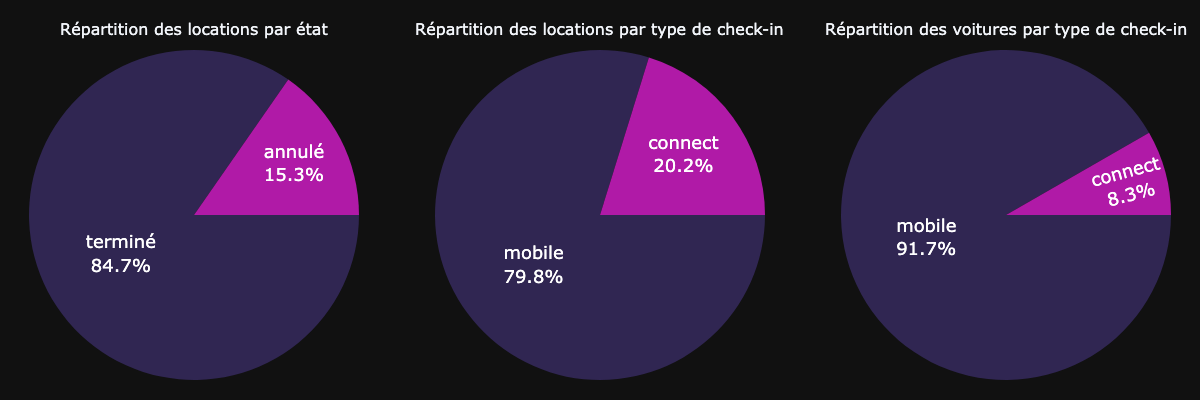

In [117]:
rentals_by_state = (
    rentals.groupby("state")
    .size()
    .rename("nb_rentals")
    .to_frame()
    .assign(rentals_ratio_pct=lambda x: round(x / nb_rentals * 100, 2))
    .reset_index()
    .replace({"state": STATE_TR})
    .set_index("state", drop=True)
)
rentals_by_checkin_type = (
    rentals.groupby("checkin_type")
    .size()
    .rename("nb_rentals")
    .to_frame()
    .assign(rentals_ratio_pct=lambda x: round(x / nb_rentals * 100, 2))
)
checkin_type_by_car = (
    rentals
    .drop_duplicates(subset=["car_id"])
    .groupby("checkin_type")
    .size()
    .rename("nb_cars")
    .to_frame()
    .assign(cars_ratio_pct=lambda x: round(x / nb_cars * 100, 2))
)
print("\n\n".join(
    [
        rentals_by_state.to_string(),
        rentals_by_checkin_type.to_string(),
        checkin_type_by_car.to_string()
    ]
))

color_map_checkin = {"connect": DEFAULT_COLOR, "mobile": ALT_COLOR}
pie_configs = [
    {
        "data": rentals["state"].map(STATE_TR),
        "title": "Répartition des locations par état",
        "cm": {"annulé": DEFAULT_COLOR, "terminé": ALT_COLOR},
    },
    {
        "data": rentals["checkin_type"],
        "title": "Répartition des locations par type de check-in",
        "cm": color_map_checkin,
    },
    {
        "data": rentals.drop_duplicates(subset=["car_id"])["checkin_type"],
        "title": "Répartition des voitures par type de check-in",
        "cm": color_map_checkin,
    },
]

fig_name = "Repartition locations par etat et par type de check-in et des voitures par type de check-in"
index_image = make_pies(configs=pie_configs, figure_name=fig_name, idx_image=index_image, rotation=90)

In [118]:
rentals_by_state_and_by_checkin_type_abs_pct = (
    rentals
    .groupby(["state", "checkin_type"])
    .size()
    .unstack()
    .reset_index()
    .replace({"state": STATE_TR})
    .set_index("state", drop=True)
    .assign(total_by_state=lambda x: x.sum(axis=1))
    .rename(columns={"total_by_state": "total par état"})
    .div(nb_rows).mul(100).round(2)
)
rentals_by_state_and_by_checkin_type_abs_pct.loc["total par type de check-in"] = rentals_by_state_and_by_checkin_type_abs_pct.sum()

rentals_by_state_and_by_checkin_type_rel_pct = rentals_by_state_and_by_checkin_type_abs_pct.copy()
rentals_by_state_and_by_checkin_type_rel_pct.drop(index="total par type de check-in", columns="total par état", inplace=True)
rentals_by_state_and_by_checkin_type_rel_pct = rentals_by_state_and_by_checkin_type_rel_pct.div(rentals_by_state_and_by_checkin_type_rel_pct.sum()).mul(100).round(2)

print(
    "Répartition des locations par état et par type de check-in\n\n" +
    "- en pourcentage du nombre total de locations :\n" +
    rentals_by_state_and_by_checkin_type_abs_pct.to_string() + "\n\n" +
    "- en pourcentage du nombre de locations par type de check-in :\n" +
    rentals_by_state_and_by_checkin_type_rel_pct.to_string()
)

Répartition des locations par état et par type de check-in

- en pourcentage du nombre total de locations :
checkin_type                connect  mobile  total par état
state                                                      
annulé                         3.74   11.58           15.32
terminé                       16.47   68.21           84.68
total par type de check-in    20.21   79.79          100.00

- en pourcentage du nombre de locations par type de check-in :
checkin_type  connect  mobile
state                        
annulé          18.51   14.51
terminé         81.49   85.49


15,3% des locations sont annulées, sans que nous puissions en connaître la cause depuis le dataset fourni.

Le dispositif de check-in "Connect" est installé sur seulement 8,3% du parc, mais représente 20,2% des locations.

Les annulations sont plus fréquentes pour connect (18,5%) que sur mobile (14,5%). Il est possible que les conditions d'annulation sont différentes selon le type de check-in.

### 2.2 Délai au check-out

#### 2.2.1 Disponibilité des données

In [119]:
missing_by_state = (
    rentals
    .groupby("state")
    .agg({"delay_at_checkout_in_minutes": lambda x: x.isna().sum()})
    .reset_index()
    .replace({"state": STATE_TR})
    .rename(
        columns={
            "state": "État",
            "delay_at_checkout_in_minutes": "Valeurs manquantes"
        }
    )
    .set_index("État", drop=True)
)
missing_by_state["Valeurs manquantes (%)"] = missing_by_state["Valeurs manquantes"].div(rentals_by_state["nb_rentals"]).mul(100).round(2)
missing_by_state["Valeurs manquantes"] = missing_by_state["Valeurs manquantes"]
print(
    "Valeurs manquantes pour chaque état :\n" +
    missing_by_state.to_string()
)

canceled_rentals_having_chekout_value = (rentals['state'] == "canceled") & (~rentals['delay_at_checkout_in_minutes'].isna())
print(
    '\nLigne(s) en cause pour état="annulé" :\n' +
    rentals[canceled_rentals_having_chekout_value].to_string()
)

Valeurs manquantes pour chaque état :
         Valeurs manquantes  Valeurs manquantes (%)
État                                               
annulé                 3264                   99.97
terminé                1700                    9.42

Ligne(s) en cause pour état="annulé" :
       rental_id  car_id checkin_type     state  delay_at_checkout_in_minutes  previous_ended_rental_id  time_delta_with_previous_rental_in_minutes
21002     559126  379544       mobile  canceled                        -17468                      <NA>                                        <NA>


Concernant l'état "annulé", la quasi-totalité des lignes n'ont pas de valeur pour la colonne `delay_at_checkout_in_minutes` et cela est logique.
Une seule ligne possède une valeur :
- soit c'est une erreur dans la colonne `delay_at_checkout_in_minutes` et il ne devrait pas y avoir de valeur,
- soit la colonne `state` est mal définie et la valeur devrait être à "ended".

Cela n'aura aucune conséquence sur le reste de l'EDA, donc nous ne faisons aucune modification.

Concernant l'état "terminé", les valeurs manquantes représentent 9,42% de toutes les locations terminées.
C'est un taux acceptable pour continuer l'EDA.
Les lignes correspondantes seront écartées de l'étude, à chaque fois que la variable sera nécessaire.

#### 2.2.2 Vue binaire du délai au check-out ("en retard" vs "en avance")

Figure 02_Repartition_retard_au_check_out_global_et_par_type_de_check_in exportée vers ../images/02_Repartition_retard_au_check_out_global_et_par_type_de_check_in.png


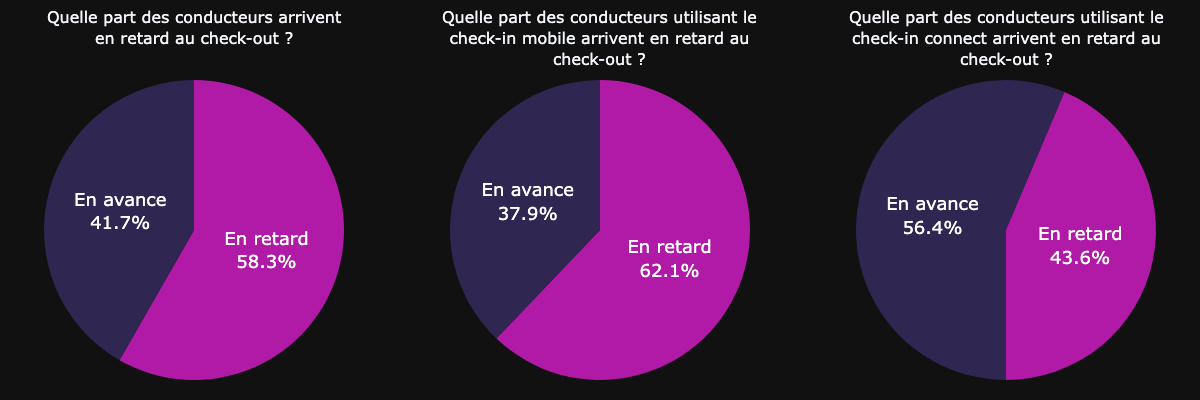

In [120]:
delays = rentals["delay_at_checkout_in_minutes"].copy().dropna()
late_vs_checkin_type = (
    rentals[["checkin_type", "delay_at_checkout_in_minutes"]]
    .copy()
    .dropna()
    .assign(late=lambda x: (x["delay_at_checkout_in_minutes"] >= 0).map({True: "En retard", False: "En avance"}))
    .drop(columns=["delay_at_checkout_in_minutes"])
)

late = late_vs_checkin_type["late"]
late_mobile = late_vs_checkin_type[late_vs_checkin_type["checkin_type"] == "mobile"]["late"]
late_connect = late_vs_checkin_type[late_vs_checkin_type["checkin_type"] == "connect"]["late"]

color_map = {"En retard": DEFAULT_COLOR, "En avance": ALT_COLOR}
pie_configs = [
    {
        "data": late,
        "title": "Quelle part des conducteurs arrivent<br>en retard au check-out ?",
        "cm": color_map
    },
    {
        "data": late_mobile,
        "title": "Quelle part des conducteurs utilisant le<br>check-in mobile arrivent en retard au<br>check-out ?",
        "cm": color_map
    },
    {
        "data": late_connect,
        "title": "Quelle part des conducteurs utilisant le<br>check-in connect arrivent en retard au<br>check-out ?",
        "cm": color_map,
        "extra_rotation": 180
    },
]

fig_name = "Repartition retard au check out global et par type de check in"
index_image = make_pies(configs=pie_configs, figure_name=fig_name, idx_image=index_image, y_pos=1.25, margin=dict(t=80, b=20, l=20, r=20))

Une large majorité des conducteurs (58,3%) arrivent en retard pour le check-out.
Par ailleurs, la proportion en retard est supérieure quand il s'agit de rendre le véhicule au propriétaire (62,1%)
plutôt que de le laisser garé à un endroit (43,6%).

#### 2.2.3 Distribution des délais au check-out

In [121]:
print(
    "Statistiques sur les données brutes du délai au check-out :\n\n" +
    delays.describe().to_string()
)

Statistiques sur les données brutes du délai au check-out :

count        16346.0
mean       59.701517
std      1002.561635
min         -22433.0
25%            -36.0
50%              9.0
75%             67.0
max          71084.0


Comme montré ci-dessus, certaines valeurs de délais sont très éloignées de la médiane ou de la moyenne.
Elles faussent les statistiques ou la visualisation de la distribution.
Par conséquent, nous les excluons de l'EDA en utilisant la méthode de Tukey, adaptée aux distributions temporelles avec des longues queues.

Application de la méthode de Tukey (k=3) pour filtrer les délais aberrants
Q1  = -36 min
Q3  = 67 min
IQR = 103 min
Bornes : [-345, 376] min
Données conservées : 91.4%
Données supprimées : 8.6%

Figure 03_Distribution_delais_check_out exportée vers ../images/03_Distribution_delais_check_out.png


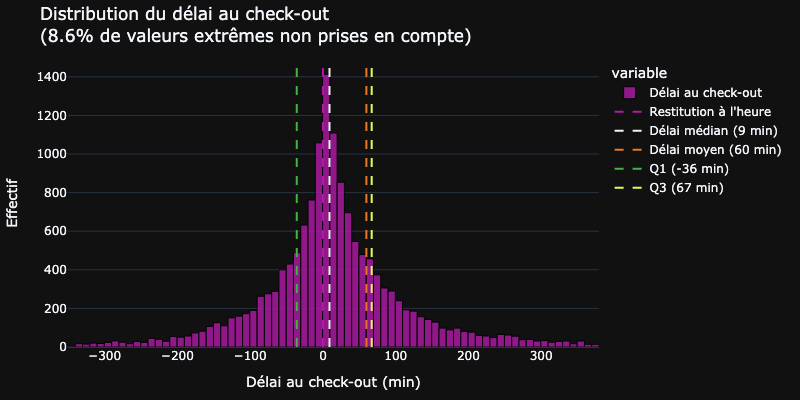

In [122]:
print("Application de la méthode de Tukey (k=3) pour filtrer les délais aberrants")
median = delays.median()
mean = delays.mean()
q1 = delays.quantile(0.25)
q3 = delays.quantile(0.75)
iqr = q3 - q1
print(f"Q1  = {q1:.0f} min\nQ3  = {q3:.0f} min\nIQR = {iqr:.0f} min")

k = 3  # facteur pour valeurs extrêmes (1.5 pour modérées)
lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

# Filtrage pour la visualisation uniquement
filtered_delays = delays[(delays >= lower_bound) & (delays <= upper_bound)]

kept_ratio = len(filtered_delays) / len(delays)
print(f"Bornes : [{lower_bound:.0f}, {upper_bound:.0f}] min")
print(f"Données conservées : {kept_ratio:.1%}")
print(f"Données supprimées : {1 - kept_ratio:.1%}\n")


fig = px.histogram(
    filtered_delays,
    nbins=100,
    color_discrete_sequence=[DEFAULT_COLOR],
)
fig.update_traces(name="Délai au check-out", showlegend=True)
fig.update_xaxes(title="Délai au check-out (min)")
fig.update_yaxes(title="Effectif")
fig.update_traces(marker_line_color="black", marker_line_width=1, opacity=0.8)

line_configs = [
    {"name": "Restitution à l'heure", "x": 0},
    {"name": f"Délai médian ({median:.0f} min)", "x": median},
    {"name": f"Délai moyen ({mean:.0f} min)", "x": mean},
    {"name": f"Q1 ({q1:.0f} min)", "x": q1},
    {"name": f"Q3 ({q3:.0f} min)", "x": q3}
]
for col_idx, cfg in enumerate(line_configs, start=1):
    fig.add_trace(
        go.Scatter(
            x=[cfg["x"]] * 2,
            y=[0, 1],
            mode="lines",
            line=dict(color=GETAROUND_CATEGORICAL[col_idx - 1], dash="dash"),
            name=cfg["name"],
            yaxis="y2",  # axe secondaire pour s'étendre sur toute la hauteur
        )
    )

fig.update_layout(
    width=800,
    height=400,
    showlegend=True,
    margin=dict(t=60, b=20, l=20, r=20),
    yaxis2=dict(
        overlaying="y",
        range=[0, 1],
        showgrid=False,
        showticklabels=False,
        visible=False,  # Axe secondaire invisible
    ),
    title=dict(
        text=(f"Distribution du délai au check-out<br>" +
              f"({1 - kept_ratio:.1%} de valeurs extrêmes non prises en compte)"),
        y=0.95,
        yanchor="top"
    ),
)

fig_name = "Distribution delais check out"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Après filtrage des valeurs extrêmes, à première vue, nous constatons que le délai au check-out est visuellement plutôt symétrique et équilibré.
En analysant plus précisément, nous notons qu'il existe un léger déséquilibre, avec plus de délais positifs (retard) que de négatifs (avance).
La moyenne est d'exactement une heure de retard.
La moitié des utilisateurs rendent le véhicule avec au moins 9 minutes de retard, et un quart avec plus d'une heure de retard (67 min).

Figure 04_Distribution_delais_check_out_par_type_de_check_in exportée vers ../images/04_Distribution_delais_check_out_par_type_de_check_in.png


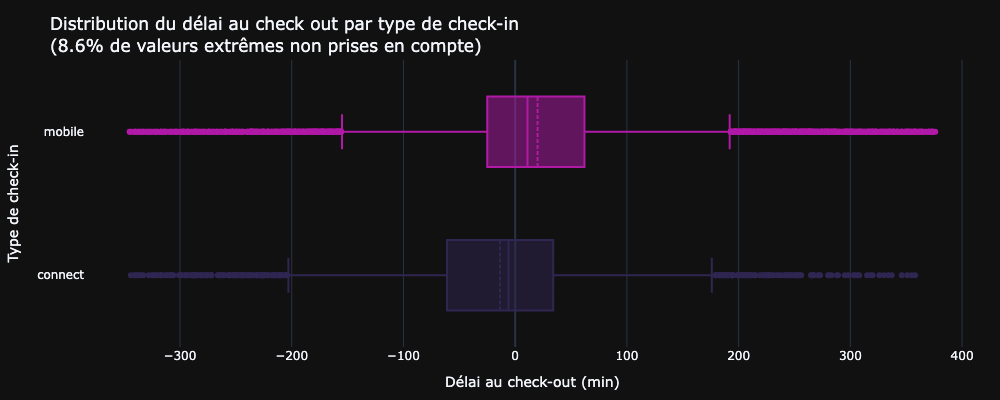

In [123]:
fig = px.box(
    rentals[
        (rentals["state"] == "ended")
        & (lower_bound <= rentals["delay_at_checkout_in_minutes"])
        & (rentals["delay_at_checkout_in_minutes"] <= upper_bound)
    ],
    y="checkin_type",
    x="delay_at_checkout_in_minutes",
    orientation="h",
    color="checkin_type",
    color_discrete_sequence=[DEFAULT_COLOR, ALT_COLOR],
    title=("Distribution du délai au check out par type de check-in" +
           f"<br>({1 - kept_ratio:.1%} de valeurs extrêmes non prises en compte)")
)
fig.update_traces(
    hoveron="boxes",
    boxmean=True,  # ajoute la moyenne (point ou ligne pointillée)
)
fig.update_yaxes(title="Type de check-in")
fig.update_xaxes(title="Délai au check-out (min)")
fig_name = "Distribution delais check out par type de check in"
fig.update_layout(height=400, showlegend=False, margin=dict(t=60, b=20, l=20, r=20),)
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Les locations via le check-in connect génèrent moins de retards au check-out que celles faites via le mobile du propriétaire de la voiture.
Comme observé précédemment, les locations avec connect ont même tendance à se terminer en avance.

Statistiques du délai au check-out (en minutes) :

|         | connect | mobile |
|---------|---------|--------|
| médiane | -6      | +11    |
| moyenne | -13,6   | +20,0  |
| Q1      | -61     | -25    |
| Q3      | +34     | +62    |

### 2.3 Locations consécutives

Comme défini dans la documentation fournie, deux locations sont considérées comme consécutives si elles sont suffisamment rapprochées dans le temps,
c'est-à-dire s'il y a moins de 12 heures entre l'heure planifiée de check-out de la précédente et l'heure planifiée de check-in de la suivante.

Figure 05_Proportion_locations_successives_et_retard_locations_initiales exportée vers ../images/05_Proportion_locations_successives_et_retard_locations_initiales.png


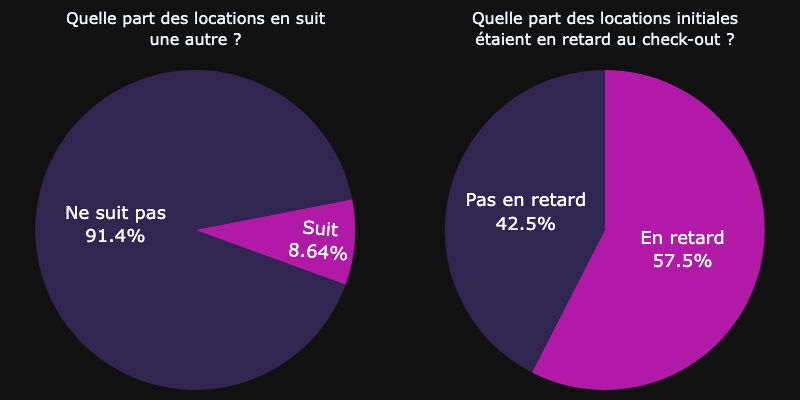

In [124]:
consecutive_rentals = add_consecutive_flag(rentals)

pie_configs = [
    {
        "data": consecutive_rentals["is_consecutive"].map({True: "Suit", False: "Ne suit pas"}),
        "title": "Quelle part des locations en suit<br>une autre ?",
        "cm": {"Suit": DEFAULT_COLOR, "Ne suit pas": ALT_COLOR},
        "extra_rotation": 110
    },
    {
        "data": (
            (consecutive_rentals["delay_at_checkout_in_minutes"] > 0)
            .map({True: "En retard", False: "Pas en retard"})
        ),
        "title": "Quelle part des locations initiales<br>étaient en retard au check-out ?",
        "cm": {"En retard": DEFAULT_COLOR, "Pas en retard": ALT_COLOR}
    }
]
fig_name = "Proportion locations successives et retard locations initiales"
index_image = make_pies(configs=pie_configs, figure_name=fig_name, idx_image=index_image, y_pos=1.2, margin=dict(t=70, b=10, l=10, r=10))

Seulement 8,64% des locations ont suivi une autre (dans les deux heures après le check-out).
Les locations ayant précédé celles-ci ont été en retard à hauteur de 57,5%,
c'est-à-dire dans une proportion similaire aux locations dans leur globalité (58,3%).

### 2.4 Friction

Le problème principal que Getaround cherche à régler est la friction.
Il s'agit des cas où une location précédente s'est terminée avec un retard au check-out si important que la
location suivante a été retardée au check-in.
Ces cas des figures peut occasionner des perturbations ou un mécontentement des propriétaires et des utilisateurs,
et provoquer des annulations, donc une perte de chiffre d'affaires (pour Getaround et les propriétaires).

Figure 06_Repartition_friction_globale_et_parmi_locations_consecutives_et_par_type_check_in exportée vers ../images/06_Repartition_friction_globale_et_parmi_locations_consecutives_et_par_type_check_in.png


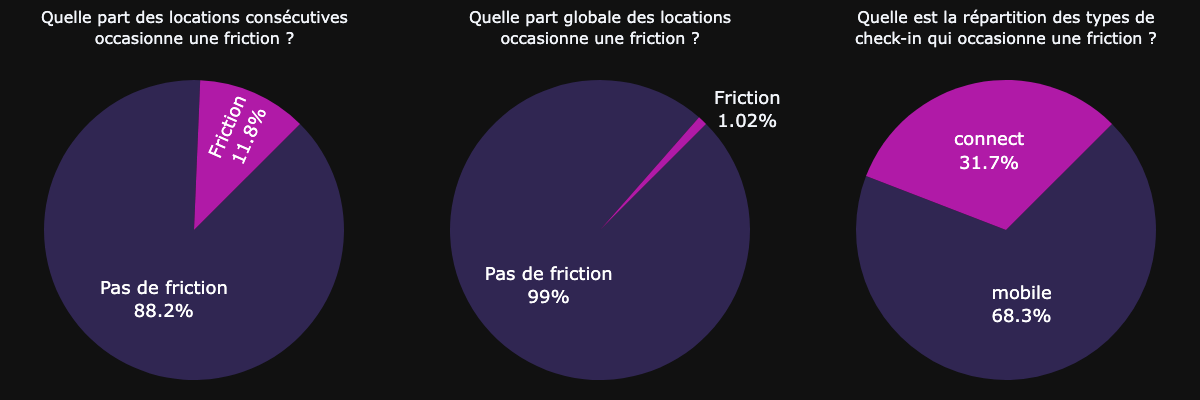

In [125]:
consecutive_rentals = merge_with_previous_rental(consecutive_rentals)
consecutive_rentals = add_friction_flag(consecutive_rentals)

FRICTION_TR = {True: "Friction", False: "Pas de friction"}
friction_global_shares = consecutive_rentals["has_friction"].replace(FRICTION_TR)
friction_consecutive_rental_shares = (
    consecutive_rentals[consecutive_rentals["is_consecutive"]]
    ["has_friction"]
    .replace(FRICTION_TR)
)
friction_per_checkin_type = (
    consecutive_rentals[
        (consecutive_rentals["is_consecutive"])
        & (consecutive_rentals["has_friction"])
    ]
    ["checkin_type"]
)

color_map_friction = {"Friction": DEFAULT_COLOR, "Pas de friction": ALT_COLOR}
pie_configs = [
    {
        "data": friction_consecutive_rental_shares,
        "title": "Quelle part des locations consécutives<br>occasionne une friction ?",
        "cm": color_map_friction,
    },
    {
        "data": friction_global_shares,
        "title": "Quelle part globale des locations<br>occasionne une friction ?",
        "cm": color_map_friction,
    },
    {
        "data": friction_per_checkin_type,
        "title": "Quelle est la répartition des types de<br>check-in qui occasionne une friction ?",
        "cm": {"connect": DEFAULT_COLOR, "mobile": ALT_COLOR},
    },
]
fig_name = "Repartition friction globale et parmi locations consecutives et par type check in"
index_image = make_pies(configs=pie_configs, figure_name=fig_name, idx_image=index_image, rotation=45, y_pos=1.25, margin=dict(t=80, b=20, l=20, r=20))

Dans le graphique précédent, nous avons montré que les locations successives représentent 8,64% des locations.
Parmi celles-ci, 11,8% occasionnent une friction.
Au global, la friction apparaît dans 1,02% des locations.

Parmi ces cas, 31,7% interviennent avec un check-in via connect et 68,% sur mobile.
Cela montre une proportion de friction venant de connect supérieure à la proportion d'utilisation de ce check-in
pour les locations (31,7% vs 20,2%).

Bien qu'ils ne se contredisent pas, ce constat est à mettre en opposition avec celui ayant montré que les utilisateurs
sont généralement en avance pour le check-out quand ils utilisent connect, et en retard quand ils utilisent la version
mobile.

Est-ce que ces retards, peu importe le type de check-in, occasionnent des annulations ? Nous l'étudions ci-après.

Figure 07_Taux_annulation_si_locations_successives_ou_si_friction exportée vers ../images/07_Taux_annulation_si_locations_successives_ou_si_friction.png


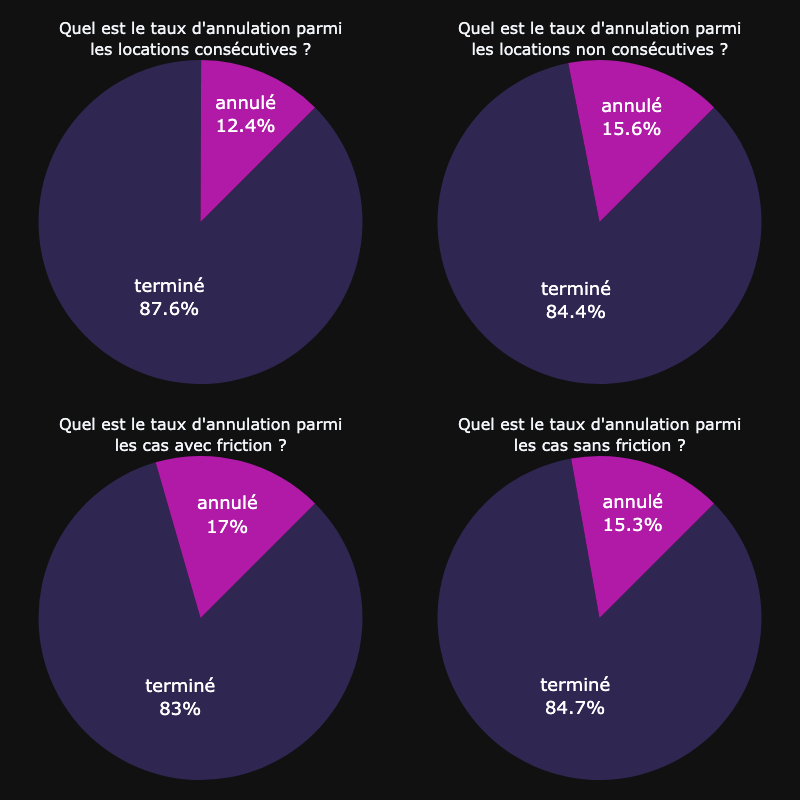

In [126]:
state_vs_consecutive_rentals = (
    consecutive_rentals[["state", "is_consecutive"]]
    .copy()
    .replace(STATE_TR)
)
cons = state_vs_consecutive_rentals[state_vs_consecutive_rentals["is_consecutive"]]["state"]
not_cons = state_vs_consecutive_rentals[~state_vs_consecutive_rentals["is_consecutive"]]["state"]

state_vs_friction = (
    consecutive_rentals[["state", "has_friction"]]
    .copy()
    .replace({"state": STATE_TR})
)
fric = state_vs_friction[state_vs_friction["has_friction"] == True]["state"]
no_fric = state_vs_friction[state_vs_friction["has_friction"] == False]["state"]

color_map = {"annulé": DEFAULT_COLOR, "terminé": ALT_COLOR}
pie_configs = [
    {
        "data": cons,
        "title": "Quel est le taux d'annulation parmi<br>les locations consécutives ?",
        "cm": color_map,
    },
    {
        "data": not_cons,
        "title": "Quel est le taux d'annulation parmi<br>les locations non consécutives ?",
        "cm": color_map,
    },
    {
        "data": fric,
        "title": "Quel est le taux d'annulation parmi<br>les cas avec friction ?",
        "cm": color_map,
    },
    {
        "data": no_fric,
        "title": "Quel est le taux d'annulation parmi<br>les cas sans friction ?",
        "cm": color_map,
    },
]

fig_name = "Taux annulation si locations successives ou si friction"
index_image = make_pies(configs=pie_configs, figure_name=fig_name, idx_image=index_image, rotation=45, margin=dict(t=60, b=20, l=20, r=20))

Dans un premier temps, ces graphiques montrent que les locations consécutives ne sont pas la cause première
d'annulation.
En effet, leur taux d'annulation est plus faible (12,4%) que les locations non rapprochées (15,6%).
Pour rappel, le taux d'annulation global est de 15,3%.

Dans un second temps, il est à noter que la friction est une vraie cause d'augmentation du taux d'annulation.
Ce taux monte à 17%, soit une augmentation de 1,7% par rapport à la moyenne.

Cela illustre le problème métier auquel Getaround fait face : diminuer la friction pour éviter une baisse de chiffre d'affaires.

### 2.5 Délai entre deux locations consécutives

En guise de dernière étape avant de tenter de trouver une solution au problème métier (en partie 3),
nous pouvons essayer de faire apparaître une intuition sur le seuil de délai minimum à mettre en place
entre locations consécutives afin d'éviter la friction.
Pour ce faire, nous mettons en parallèle la distribution de ce délai effectif avec celle des cas de friction.

Statistiques du délai entre deux locations successives :
count    1841.0
mean      279.0
std       255.0
min         0.0
25%        60.0
50%       180.0
75%       540.0
max       720.0

Figure 08_Distribution_délai_entre_deux_locations_consecutives exportée vers ../images/08_Distribution_délai_entre_deux_locations_consecutives.png


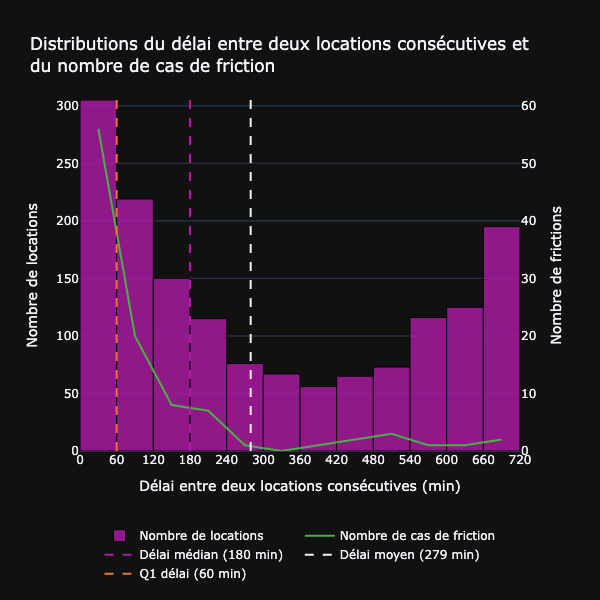

In [127]:
time_col = "time_delta_with_previous_rental_in_minutes"
time_delta = consecutive_rentals.loc[:, time_col]

print(
   "Statistiques du délai entre deux locations successives :\n" +
    time_delta.describe().round().to_string() + "\n"
)

max_time_delta = int(time_delta.max())
consecutive_rentals["time_delta_bins"] = pd.cut(
    consecutive_rentals[time_col],
    bins=range(0, max_time_delta + 1, 60),
    right=True,
)
friction_counts_per_time_delta_bins = (
    consecutive_rentals[["time_delta_bins", "has_friction", time_col]]
    .groupby("time_delta_bins", observed=True)
    .agg({"has_friction": "sum", time_col: "count"})
    .rename(columns={"has_friction": "Nombre de cas de friction", time_col: "Nombre de locations"})
    .reset_index()
    .assign(a=lambda df: df["time_delta_bins"].apply(lambda x: 0.5*(x.left + x.right)))
    .rename(columns={"a": "Délai entre deux locations successives (min)"})
    .drop(columns="time_delta_bins")
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=friction_counts_per_time_delta_bins["Délai entre deux locations successives (min)"],
        y=friction_counts_per_time_delta_bins["Nombre de locations"],
        width=60,  # en unités de l'axe X
        name="Nombre de locations",
        marker=dict(color=DEFAULT_COLOR, line=dict(color="black", width=1)),
        opacity=0.8
    )
)

fig.add_trace(
    go.Scatter(
        x=friction_counts_per_time_delta_bins["Délai entre deux locations successives (min)"],
        y=friction_counts_per_time_delta_bins["Nombre de cas de friction"],
        mode="lines",
        line=dict(color=GETAROUND_CATEGORICAL[3]),
        name="Nombre de cas de friction",
        yaxis="y2"
    )
)

# Trick to set the range of y2 axis and avoid double grids
max_y1 = float(friction_counts_per_time_delta_bins["Nombre de locations"].max())
max_y2 = float(friction_counts_per_time_delta_bins["Nombre de cas de friction"].max())
n1 = int(np.log10(max_y1))
n3 = int(np.log10(max_y2))
max_y1_round_down = int(int(max_y1/ 10 ** n1) * 10 ** n1)
max_y2_round_up = int(int(1 + max_y2/ 10 ** n3) * 10 ** n3)
max_y2_round_up = max_y1 / max_y1_round_down * max_y2_round_up

t_med, t_mean, t_q1 = time_delta.median(), time_delta.mean(), time_delta.quantile(0.25)
line_configs = [
    {"name": f"Délai médian ({t_med:.0f} min)", "x": t_med},
    {"name": f"Délai moyen ({t_mean:.0f} min)", "x": t_mean},
    {"name": f"Q1 délai ({t_q1:.0f} min)", "x": t_q1},
]
range_y3 = [0, 1]
for col_idx, cfg in enumerate(line_configs, start=1):
    fig.add_trace(
        go.Scatter(
            x=[cfg["x"]] * 2,
            y=range_y3,
            mode="lines",
            line=dict(color=GETAROUND_CATEGORICAL[col_idx - 1], dash="dash"),
            name=cfg["name"],
            yaxis="y3"
        )
    )

fig.update_layout(
    width=600,
    height=600,
    showlegend=True,
    title=dict(text="Distributions du délai entre deux locations consécutives et<br>" +
                    "du nombre de cas de friction"),
    xaxis=dict(
        title="Délai entre deux locations consécutives (min)",
        dtick=60
    ),
    yaxis=dict(
        title="Nombre de locations",
        range=[0, max_y1],
    ),
    yaxis2=dict(
        overlaying="y",
        side="right",
        title="Nombre de frictions",
        range=[0, max_y2_round_up]
    ),
    yaxis3=dict(
        overlaying="y",
        visible=False,  # Axe secondaire invisible
        range=range_y3,  # et calé sur 0-1 (proportion de la hauteur)
        showgrid=False,
        showticklabels=False,
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,
        xanchor="center",
        x=0.5,
    ),
)

fig_name = "Distribution délai entre deux locations consecutives"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Nous observons une distribution du délai entre deux locations consécutives assez remarquable : la maximum global est pour la tranche 0-1 h de délai,
ensuite les effectifs décroissent de manière monotone jusqu'à l'intervalle 6-7 h, puis ils croissent
jusqu'à la borne supérieure de 11-12 h.
Par conséquent, nous avons deux maxima : un global aux délais très courts et un local aux délais enregistrés
les plus longs.
Par ailleurs, la décroissance observée est assez prononcée, surtout dans les trois premières heures.

En parallèle, nous observons une décroissance du nombre de cas de friction en fonction du délai, quasi monotone.
Celle-ci est encore plus prononcée dans les 2-3 premières heures que celle notée pour les locations successives.
Ensuite, la friction est quasi stable et très faible, de la cinquième à la douzième heure, oscillant en 0 et 3 cas.

En résumé, l'optimum de seuil de délai entre deux locations consécutives devrait se situer entre 1 et 3 heures.
Nous allons le vérifier dans la partie 3.

---

## Partie 3 - Seuil optimal entre deux locations consécutives

Dans cette partie, nous recherchons le seuil optimal à mettre en place pour empêcher toute location de voiture pendant un certain délai démarrant à l'heure planifié de check-out de la location précédente pour cette même voiture.

Pour ce faire, nous testons des valeurs de seuils et, pour chaque seuil, nous notons :
- le taux de résolution, c'est-à-dire le taux de locations où la friction aurait été évitée (le délai permet de couvrir le retard au check-out de la location précédente),
- le taux de blocage, c'est-à-dire le taux de locations qui n'auraient pas pu être enregistrées (le délai empêche une location de voiture de commencer à l'heure prévue).

Remarques :
- Le taux de résolution est défini comme le nombre de cas résolus par rapport au nombre de cas problématiques (i.e., avec friction).
- Le taux de blocage est défini comme le nombre de cas bloqués par rapport au nombre de locations consécutives.

Définition du seuil optimal :
Le seuil optimal est le délai entre deux locations successives qui permet de maximiser la différence entre le taux de résolution et le taux de blocage.
Il peut être défini de manière globale ou bien sur un seul type de check-in.

### 3.1 Simulation

In [128]:
def assess_thresholds(
        df: pd.DataFrame,
        t_min: int=0,
        t_max: int=720,
        t_step: int=1,
        scope: str="all"
) -> pd.DataFrame:
    df = df.copy()
    if scope not in ["all", "mobile", "connect"]:
        raise ValueError("scope must be either 'all', 'mobile' or 'connect'")
    if scope in ["mobile", "connect"]:
        df = df[df["checkin_type"] == scope]
    df = add_friction_flag(merge_with_previous_rental(add_consecutive_flag(df)))
    cons_df = df[df["is_consecutive"]]
    fric_df = df[df["has_friction"]]
    nb_cons = cons_df.shape[0]
    nb_fric = fric_df.shape[0]
    prev_delay_col = "previous_rental_delay_at_checkout_in_minutes"
    time_delta_col = "time_delta_with_previous_rental_in_minutes"
    list_dict = []
    for t in range(t_min, t_max + 1, t_step):
        nb_solved = (fric_df[prev_delay_col] - fric_df[time_delta_col] <= t).astype(int).sum()
        nb_blocked = (cons_df[time_delta_col] < t).sum()
        list_dict.append(
            {
                "scope": scope,
                "threshold": t,
                "nb_solved": nb_solved,
                "resolution_rate": round(100 * nb_solved / nb_fric, 1),
                "nb_blocked": nb_blocked,
                "blocking_rate": round(100 * nb_blocked / nb_cons, 1),
            }
        )
    return pd.DataFrame(list_dict)


def polynomial_fit(df, degree, mode: str="diff"):
    mask = df[["threshold", "resolution_rate", "blocking_rate"]].notna().all(axis=1)
    x = df.loc[mask, "threshold"].values
    if mode == "diff":
        y = df.loc[mask, "resolution_rate"].values - df.loc[mask, "blocking_rate"].values
    elif mode == "res":
        y = df.loc[mask, "resolution_rate"].values
    elif mode == "blk":
        y = df.loc[mask, "blocking_rate"].values
    else:
        raise ValueError("mode must be either 'diff', 'res' or 'blk'")
    bounds = [x.min(), x.max()]
    return np.polynomial.Polynomial.fit(x, y, deg=list(range(1, degree + 1)), domain=bounds, window=bounds)


def compute_blocking_rate(df: pd.DataFrame, t: int | float, scope: str="all") -> int | float:
    return df[(df["scope"] == scope) & (df["threshold"] <= float(t))]["blocking_rate"].max()


def compute_blocked_rentals(df: pd.DataFrame, t: int | float, scope: str="all") -> int | float:
    return df[(df["scope"] == scope) & (df["threshold"] <= float(t))]["nb_blocked"].max()


def compute_resolution_rate(df: pd.DataFrame, t: int | float, scope: str="all") -> int | float:
    return df[(df["scope"] == scope) & (df["threshold"] <= float(t))]["resolution_rate"].max()


def compute_friction_free_rentals(df: pd.DataFrame, t: int | float, scope: str="all") -> int | float:
    return df[(df["scope"] == scope) & (df["threshold"] <= float(t))]["nb_solved"].max()

In [129]:
results = assess_thresholds(rentals)
for scope in ["mobile", "connect"]:
    results = pd.concat([results, assess_thresholds(rentals, scope=scope)], ignore_index=True)
results.reset_index(drop=True, inplace=True)

major_thresholds = [int(60 * t) for t in [1, 2, 3, 4, 6, 8, 10, 12]]
major_results = results[results["threshold"].isin(major_thresholds)]
print("Résultats des calculs du taux de résolution (de la friction) et " +
      "du taux de blocage\nen fonction du seuil de délai introduit " +
      "entre deux locations consécutives :\n\n" +
      major_results.to_string(index=False)
)

Résultats des calculs du taux de résolution (de la friction) et du taux de blocage
en fonction du seuil de délai introduit entre deux locations consécutives :

  scope  threshold  nb_solved  resolution_rate  nb_blocked  blocking_rate
    all         60        152             69.7         401           21.8
    all        120        177             81.2         666           36.2
    all        180        194             89.0         870           47.3
    all        240        198             90.8        1001           54.4
    all        360        205             94.0        1170           63.6
    all        480        206             94.5        1290           70.1
    all        600        209             95.9        1449           78.7
    all        720        209             95.9        1711           92.9
 mobile         60        103             69.1         220           21.4
 mobile        120        119             79.9         371           36.1
 mobile        180        

Comme nous le verrons juste après, les taux par rapport en fonction des seuils testés subissent des paliers.
Pour se soustraire de ces imperfections, nous effectuons un lissage polynomial directement sur la différence des taux.
Nous trouvons que, visuellement, un degré 7 permet de capturer finement les tendances sans introduire de bruit,
en particulier pour trouver les optima de seuils (non montré ici).

In [130]:
# Lissage par régression polynomiale de la différence entre
# le taux de résolution et le taux de blocage.
rate_diffs = {}
thresholds_smooth = np.arange(0, 721, 15)
optimal_thresholds = {}
print("Seuils optimaux :")
for checkin_type in ["connect", "mobile", "all"]:
    poly = polynomial_fit(results[results["scope"] == checkin_type], degree=7)
    rate_diffs[checkin_type] = poly
    i_optimal_threshold = np.argmax(poly(thresholds_smooth))
    optimal_threshold = thresholds_smooth[i_optimal_threshold]
    optimal_thresholds[checkin_type] = optimal_threshold
    hh = optimal_threshold // 60
    mm = optimal_threshold % 60
    checkin_type_2 = "mobile + connect" if checkin_type == "all" else checkin_type
    print(
        f"\t{checkin_type_2} :".ljust(20) + f"{hh:2d} h {mm:2d} min",
        end="\n\n" if checkin_type == "all" else "\n"
    )

Seuils optimaux :
	connect :           1 h 45 min
	mobile :            1 h 15 min
	mobile + connect :  1 h 30 min



Figure 09_Taux_de_résolution_et_de_blocage_en_fonction_du_seuil_&_visualisation_des_trois_seuils_optimaux exportée vers ../images/09_Taux_de_résolution_et_de_blocage_en_fonction_du_seuil_&_visualisation_des_trois_seuils_optimaux.png


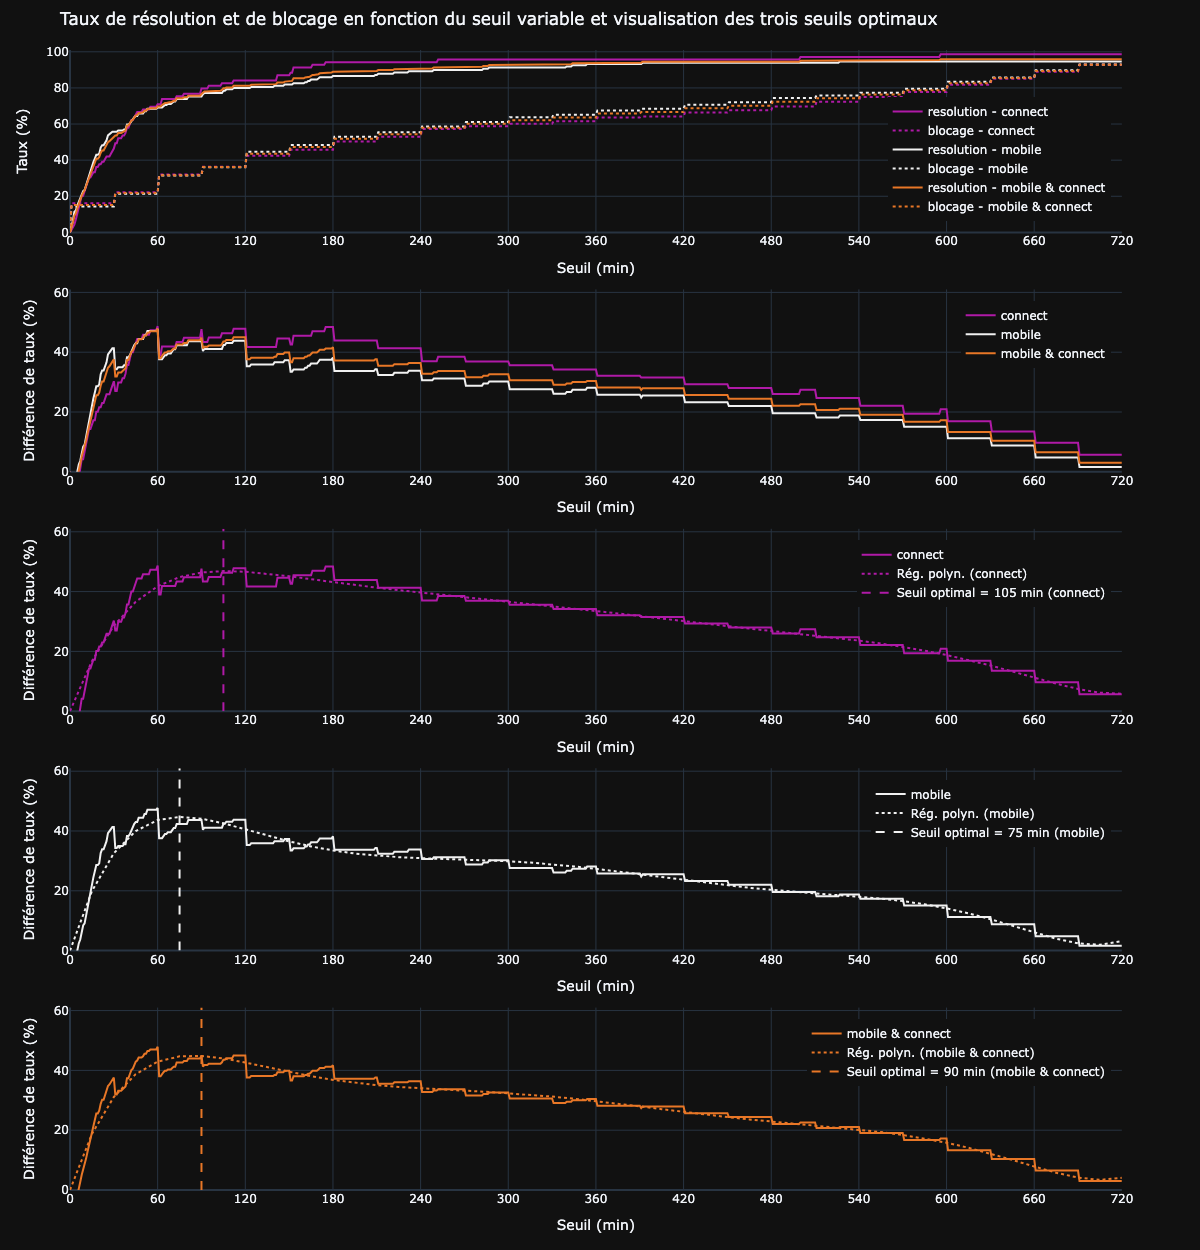

In [131]:
n_subplots = 5
specs = [[{}] for i in range(n_subplots)]
for i in [2, 3, 4]:
    specs[i][0] = {"secondary_y": True}
fig = make_subplots(rows=n_subplots, cols=1, specs=specs, vertical_spacing=0.05)

ax_names = {
    1: {"main": {"xaxis": "xaxis", "yaxis": "yaxis", "x": "x", "y": "y"}},
    2: {"main": {"xaxis": "xaxis2", "yaxis": "yaxis2", "x": "x2", "y": "y2"}},
    3: {"main": {"xaxis": "xaxis3", "yaxis": "yaxis3", "x": "x3", "y": "y3"},
        "secondary": {"xaxis": "xaxis3", "yaxis": "yaxis4", "x": "x3", "y": "y4"}},
    4: {"main": {"xaxis": "xaxis4", "yaxis": "yaxis5", "x": "x4", "y": "y5"},
        "secondary": {"xaxis": "xaxis4", "yaxis": "yaxis6", "x": "x4", "y": "y6"}},
    5: {"main": {"xaxis": "xaxis5", "yaxis": "yaxis7", "x": "x5", "y": "y7"},
        "secondary": {"xaxis": "xaxis5", "yaxis": "yaxis8", "x": "x5", "y": "y8"}},
}

# Récupération des bornes hautes des domaines de chaque sous-graphique
legend_keys, x_right, y_bottoms, y_tops = [], [], [], []
for i in range(1, n_subplots + 1):
    a = ax_names[i]["main"]
    xaxis_name = a["xaxis"]
    yaxis_name = a["yaxis"]
    x_right.append(fig.layout[xaxis_name].domain[1])
    y_bottoms.append(fig.layout[yaxis_name].domain[0])
    y_tops.append(fig.layout[yaxis_name].domain[1])
    legend_keys.append(xaxis_name.replace("xaxis", "legend"))

i = 0
for checkin_type in ["connect", "mobile", "all"]:
    for case in ["resolution", "blocking"]:
        res = results[results["scope"] == checkin_type]
        case_fr = "blocage" if case == "blocking" else case
        checkin_type_2 = "mobile & connect" if checkin_type == "all" else checkin_type
        dash = "solid" if case == "resolution" else "dot"

        fig.add_trace(
            go.Scatter(
                x=res["threshold"],
                y=res[f"{case}_rate"],
                line=dict(color=GETAROUND_CATEGORICAL[i], dash=dash),
                name=f"{case_fr} - {checkin_type_2}",
                legend=legend_keys[1 - 1]
            ),
            row=1, col=1
        )

    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["resolution_rate"] - res["blocking_rate"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=f"{checkin_type_2}",
            legend=legend_keys[2 - 1]
        ),
        row=2, col=1
    )

    j = i + 3
    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["resolution_rate"] - res["blocking_rate"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
            legend=legend_keys[j - 1]
        ),
        row=j, col=1
    )
    poly = rate_diffs[checkin_type]
    fig.add_trace(
        go.Scatter(
            x=thresholds_smooth,
            y=poly(thresholds_smooth),
            line=dict(color=GETAROUND_CATEGORICAL[i], dash="dot"),
            name=f"Rég. polyn. ({checkin_type_2})",
            legend=legend_keys[j - 1]
        ),
        row=j, col=1
    )

    t = optimal_thresholds[checkin_type]
    fig.add_trace(
        go.Scatter(
            x=[t] * 2,
            y=[0, 1],
            mode="lines",
            line=dict(color=GETAROUND_CATEGORICAL[i], dash="dash"),
            name=f"Seuil optimal = {t} min ({checkin_type_2})",
            yaxis=ax_names[j]["secondary"]["y"],
            legend=legend_keys[j - 1]
        ),
        row=j, col=1, secondary_y=True
    )

    i += 1

fig.update_xaxes(title_text="Seuil (min)")
fig.update_yaxes(title_text="Taux (%)", range=[0, 101], row=1, col=1)
for i in range(2, n_subplots + 1):
    fig.update_yaxes(
        title_text="Différence de taux (%)",
        range=[0, 61],
        secondary_y=False,
        row=i, col=1
    )

legend_params = {
    key: dict(
        xref="paper", yref="paper",
        x=x_right[i] - 0.01, y=(y_tops[i] - 0.01 if i > 0 else y_bottoms[i] + 0.01),
        xanchor="right", yanchor=("top" if i > 0 else "bottom"),
    )
    for i, key in enumerate(legend_keys)
}

secondary_axis_params = {
    ax_names[i]["secondary"]["yaxis"]: dict(
        overlaying=ax_names[i]["main"]["y"],
        visible=False,  # Axe secondaire invisible
        range=[0, 1],  # et calé sur 0-1 (proportion de la hauteur)
        showgrid=False,
        showticklabels=False,
    )
    for i in [3, 4, 5]
}

xaxis_params = {
    ax_names[i]["main"]["xaxis"]: dict(tickvals=[60 * t for t in range(13)])
    for i in range(1, n_subplots + 1)
}

fig.update_layout(
    width=1200,
    height=250 * n_subplots,
    margin = dict(t=50, b=60, l=70, r=0),
    title="Taux de résolution et de blocage en fonction du seuil variable et visualisation des trois seuils optimaux",
    **xaxis_params,
    **legend_params,
    **secondary_axis_params
)

fig_name = "Taux de resolution et de blocage en fonction du seuil et visualisation des trois seuils optimaux"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Le premier graphique ci-dessous montre que le taux de résolution croît fortement pendant la première heure,
puis plus modérément les deux heures suivantes, et lentement ensuite pour atteindre un plateau vers la sixième heure,
où le taux global est à 92,7%, alors que le taux final et maximal est de 95,9%.
Le taux de blocage croît plus modérément : dans une première phase d'environ deux heures, la pente est la plus forte,
puis il existe un vaste intervalle au centre où la croissance est très modérée et, finalement,
elle est plus forte dans les trois dernières heures. Il est à noter que, quel que soit le taux considéré,
le comportement est le même pour les deux types de check-in et les courbes se tiennent dans une bande étroite.

Le deuxième graphique permet de voir directement la différence entre le taux de résolution et le taux de blocage
en fonction du seuil testé.
Nous remarquons que le maxima est aux alentours de 120 minutes ou quelque peu avant, dans les trois cas de figure
(cas général, mobile, connect).
Ce constat valide l'intuition donnée en 2.5.

Les trois courbes ont une tendance assez nette, mais présentent des instabilités.
Pour pallier ce problème et trouver les seuils optimaux plus précisément, nous effectuons un lissage des courbes
en effectuant des régressions polynomiales.
Les trois graphiques suivants montrent chaque cas (connect, mobile, général) en traçant la courbe brute et sa version lissée.
Les seuils sont également affichés.

Nous constatons que le **seuil optimal du cas général est de 1 h 30 min**.
Il est plus bas pour le cas mobile, avec 1 h 15 min, et plus haut pour le cas connect, avec 1 h 45 min.
Les courbes montrent également que les maxima sont situés dans des intervalles relativement longs
(à plus ou moins 30 minutes autour des seuils optimaux trouvés) où les différences de taux varient très peu.
Ces valeurs proviennent d'une optimisation numérique, effectuée avec une résolution au quart d'heure près,
et méritent d'être complétée d'une vision métier avant de les mettre en place dans un environnement de production.


### 3.2 Evaluation de l'impact du seuil choisi sur l'équilibre coûts - bénéfices.

Ici, les bénéfices ne sont pas évaluées avec une conotation manière monétaire, mais plutôt en termes de satisfaction client.

Figure 10_Evaluation_couts_pour_entreprises_et_proprietaires exportée vers ../images/10_Evaluation_couts_pour_entreprises_et_proprietaires.png


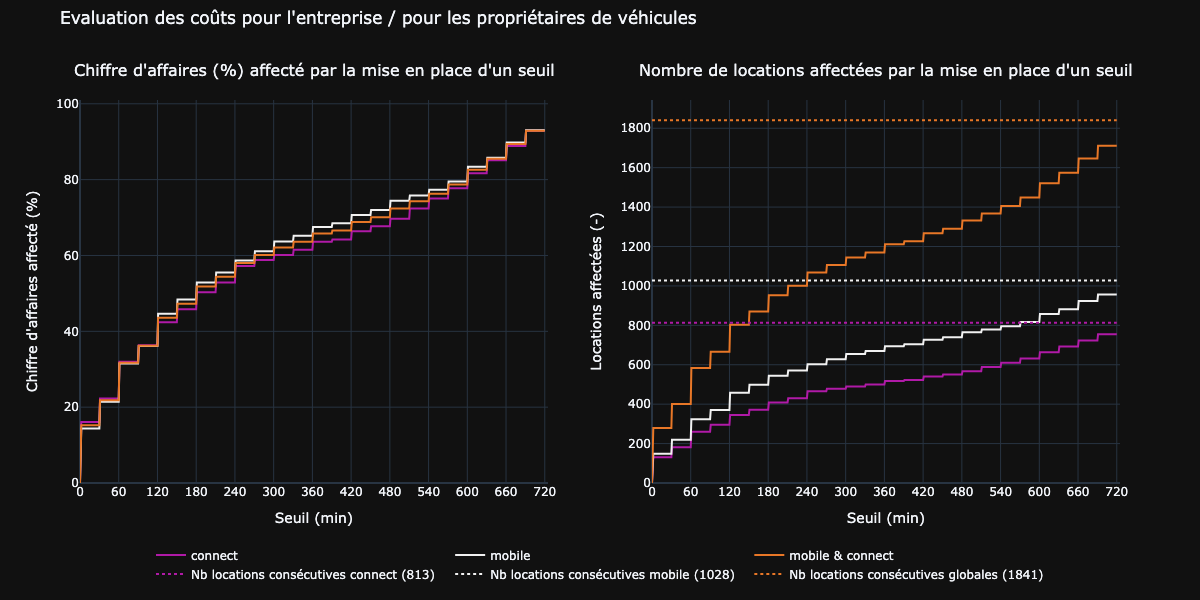

In [132]:
fig = make_subplots(
    rows=1, cols=2, specs=[[{}] * 2],
    subplot_titles=[
        "Chiffre d'affaires (%) affecté par la mise en place d'un seuil",
        "Nombre de locations affectées par la mise en place d'un seuil",
    ],
)

i = 0
case = "blocking"
for checkin_type in ["connect", "mobile", "all"]:
    res = results[results["scope"] == checkin_type]
    checkin_type_2 = "mobile & connect" if checkin_type == "all" else checkin_type
    dash = "solid" if case == "resolution" else "dot"
    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["resolution_rate"] if case == "resolution" else res["blocking_rate"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["nb_solved"] if case == "resolution" else res["nb_blocked"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
        ),
        row=1, col=2
    )
    i += 1

i = 0
for checkin_type in ["connect", "mobile", "all"]:
    checkin_cond = True if checkin_type == "all" else (consecutive_rentals["checkin_type"] == checkin_type)
    nb_cons = len(consecutive_rentals[consecutive_rentals["is_consecutive"] & checkin_cond])
    txt = "globales" if checkin_type == "all" else checkin_type
    fig.add_trace(
        go.Scatter(
            x=[0, 720],
            y=[nb_cons] * 2,
            mode="lines",
            line=dict(color=GETAROUND_CATEGORICAL[i], dash="dot"),
            name=f"Nb locations consécutives {txt} ({nb_cons})",
        ),
        row=1, col=2
    )
    i += 1

fig.update_traces(showlegend=False, row=1, col=1)
fig.update_annotations(y=1.05, yanchor="bottom")
xaxis_params = dict(title="Seuil (min)", tickvals=[60 * t for t in range(13)], range=[0, 725])
fig.update_layout(
    width=1200,
    height=600,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5,
    ),
    xaxis=xaxis_params,
    xaxis2=xaxis_params,
    yaxis=dict(title="Chiffre d'affaires affecté (%)", range=[0, 101]),
    yaxis2=dict(title="Locations affectées (-)", range=[0, None]),
    title=dict(
        text="Evaluation des coûts pour l'entreprise / pour les propriétaires de véhicules",
        y=0.98, yanchor="top",
    )
)

fig_name = "Evaluation couts pour entreprises et proprietaires"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Figure 11_Evaluation_benefices exportée vers ../images/11_Evaluation_benefices.png


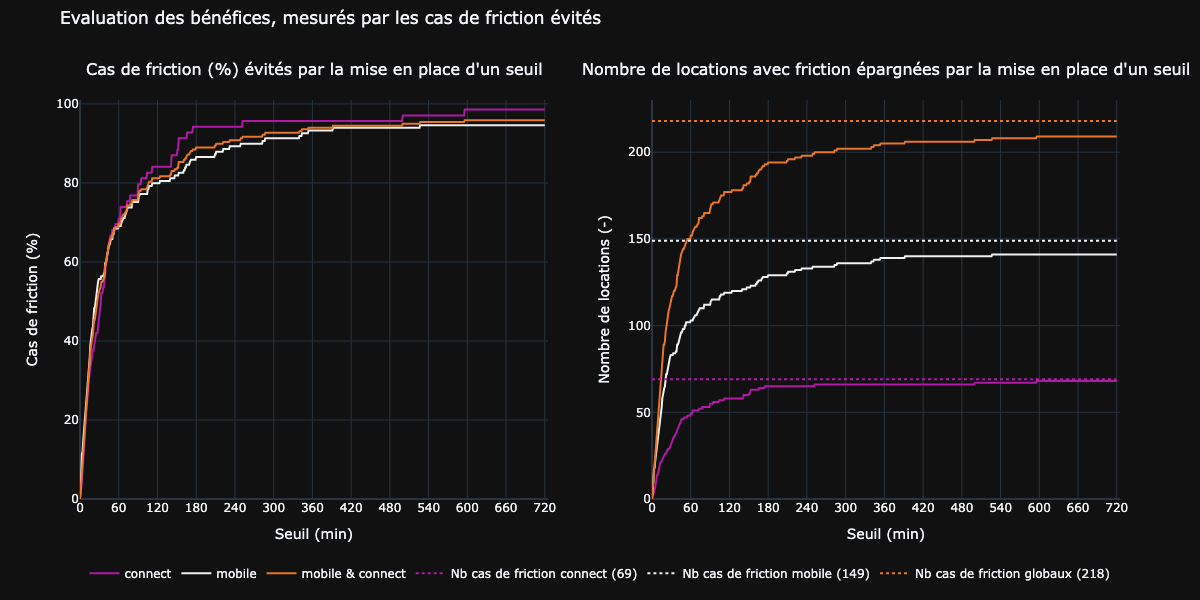

In [133]:
fig = make_subplots(
    rows=1, cols=2, specs=[[{}] * 2],
    subplot_titles=[
        "Cas de friction (%) évités par la mise en place d'un seuil",
        "Nombre de locations avec friction épargnées par la mise en place d'un seuil",
    ],
)

i = 0
case = "resolution"
for checkin_type in ["connect", "mobile", "all"]:
    res = results[results["scope"] == checkin_type]
    checkin_type_2 = "mobile & connect" if checkin_type == "all" else checkin_type
    dash = "solid" if case == "resolution" else "dot"
    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["resolution_rate"] if case == "resolution" else res["blocking_rate"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=res["threshold"],
            y=res["nb_solved"] if case == "resolution" else res["nb_blocked"],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
        ),
        row=1, col=2
    )
    i += 1

i = 0
for checkin_type in ["connect", "mobile", "all"]:
    checkin_cond = True if checkin_type == "all" else (consecutive_rentals["checkin_type"] == checkin_type)
    nb_fric = len(consecutive_rentals[consecutive_rentals["has_friction"] & checkin_cond])
    txt = "globaux" if checkin_type == "all" else checkin_type
    fig.add_trace(
        go.Scatter(
            x=[0, 720],
            y=[nb_fric] * 2,
            mode="lines",
            line=dict(color=GETAROUND_CATEGORICAL[i], dash="dot"),
            name=f"Nb cas de friction {txt} ({nb_fric})",
        ),
        row=1, col=2
    )
    i += 1

fig.update_traces(showlegend=False, row=1, col=1)
fig.update_annotations(y=1.05, yanchor="bottom")
xaxis_params = dict(title="Seuil (min)", tickvals=[60 * t for t in range(13)], range=[0, 725])
fig.update_layout(
    width=1200,
    height=600,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5,
    ),
    xaxis=xaxis_params,
    xaxis2=xaxis_params,
    yaxis=dict(title="Cas de friction (%)", range=[0, 101]),
    yaxis2=dict(title="Nombre de locations (-)", range=[0, None]),
    title=dict(
        text="Evaluation des bénéfices, mesurés par les cas de friction évités",
        y=0.98, yanchor="top",
    )
)

fig_name = "Evaluation benefices"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

**Lecture rapide et constat majeur :** inspiré de la loi des 80-20, nous constatons ~80% des cas de friction sont évités au bout de ~20% de la fenêtre de délai (en fait pour un seuil de 120 min, soit 17%), quel que soit le type de check-in.

Après ce seuil (ou peut-être après 180 min), la friction diminue très lentement, alors que les coûts engendrés augmentent de manière bien plus prononcée. Par conséquent, il est inutile de considérer un seuil supérieur à 120 min (voire 180 min).

Nous pouvons aussi noter que la moitié des cas problématiques sont résolus pour un seuil de seulement ~30 min.
Ce serait une mesure intéressante, mais manquant probablement d'efficacité.

Un autre point de repère est le seuil d'une heure : il permet d'éviter les deux tiers des cas de friction.
Pour rappel, le retard moyen des conducteurs est aussi de cette durée.

Figure 12_Benefices_vs_couts exportée vers ../images/12_Benefices_vs_couts.png


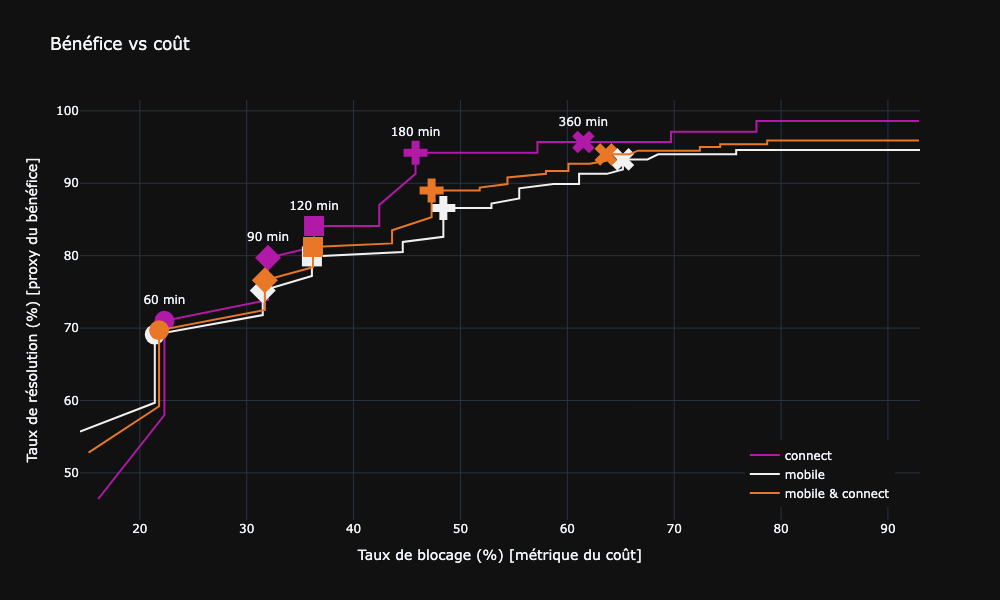

In [134]:
fig = go.Figure()

i = 0
symbols = ["circle", "diamond", "square", "cross", "x"]
thresholds = [60, 90, 120, 180, 360]
for checkin_type in ["connect", "mobile", "all"]:
    res = results[(results["scope"] == checkin_type) & (results["threshold"] >= 30)]
    checkin_type_2 = "mobile & connect" if checkin_type == "all" else checkin_type
    dash = "solid" if case == "resolution" else "dot"
    fig.add_trace(
        go.Scatter(
            x=res["blocking_rate"][::10],
            y=res["resolution_rate"][::10],
            line=dict(color=GETAROUND_CATEGORICAL[i]),
            name=checkin_type_2,
        )
    )
    for j, threshold in enumerate(thresholds):
        fig.add_trace(
            go.Scatter(
                x=[compute_blocking_rate(res, threshold, scope=checkin_type)],
                y=[compute_resolution_rate(res, threshold, scope=checkin_type)],
                mode="markers+text" if checkin_type == "connect" else "markers",
                text=[f"{threshold} min"],
                textposition="top center",
                marker=dict(
                    color=GETAROUND_CATEGORICAL[i],
                    size=20,
                    symbol=symbols[j % len(symbols)],
                ),
                showlegend=False,
            )
        )
    i += 1

fig.update_layout(
    width=1000, height=600,
    legend=dict(xref="paper", yref="paper", x=0.97, y=0.03, xanchor="right", yanchor="bottom"),
    xaxis=dict(title='Taux de blocage (%) [métrique du coût]'),
    yaxis=dict(title='Taux de résolution (%) [proxy du bénéfice]'),
    title=dict(text="Bénéfice vs coût")
)

fig_name = "Benefices vs couts"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

L'instauration de la valeur marquante de seuil précédemment relevée, 120 min, résoudrait ~80% des cas problématiques
et bloquerait dans le même temps ~36% des locations consécutives (soit ~3% de toutes les locations).

---

## Partie 4 - Recommandation finale

### 4.1 Recommandation : un déploiement en deux phases

**Phase 1 (immédiate) : seuil de 120 minutes appliqué au check-in connect uniquement.**

**Phase 2 (conditionnelle) : extension au check-in mobile après 3 à 6 mois d'observation, avec éventuel ajustement du seuil.**

Cette approche progressive est privilégiée par rapport à un déploiement immédiat sur l'ensemble du parc, pour trois raisons :

- **Faisabilité technique :** connect est nativement digital, le blocage automatique d'une réservation incompatible avec le seuil est trivial à implémenter dans le moteur de réservation. Le check-in mobile repose sur une rencontre humaine et une signature sur le téléphone du propriétaire, ce qui sort de la logique automatisée et exige des développements complémentaires.
- **Coût mesuré, parfait pour un pilote :** restreindre la mesure à connect bloque 1,4% des locations totales (295 locations), contre 3,1% pour un déploiement global (666 locations), soit environ deux fois moins de revenus impactés.
- **Stratégie d'apprentissage incrémentale :** un déploiement par paliers permet de valider les hypothèses sur un périmètre restreint avant toute généralisation. Le check-in mobile dispose en outre d'un arbitrage humain (négociation, attente, replanification) qui amortit naturellement une partie des retards, ce que connect ne propose pas.

Le seuil de 120 min reste calibré sur la loi des 80-20 : il résout environ 80% des cas de friction connect (soit ~25% de la friction totale) tout en bloquant 36% des locations consécutives connect. Il dépasse légèrement l'optimum mathématique pour connect (1 h 45 min), mais offre une zone de tolérance d'environ ±30 min sans perte notable de performance.

### 4.2 Synthèse de l'analyse

| Indicateur                                     | Valeur                           |
|------------------------------------------------|----------------------------------|
| Locations annulées (toutes causes)             | 15,3%                            |
| Locations en retard au check-out               | 58,3%                            |
| Retard moyen au check-out                      | 1 h                              |
| Locations consécutives (< 12 h)                | 8,64%                            |
| Cas de friction                                | 1,02% des locations              |
| Taux d'annulation en cas de friction           | 17,0% (+1,7 pt vs moyenne)       |
| Part de la friction portée par connect         | 31,7% (pour 20,2% des locations) |
| Seuil optimal mathématique (connect)           | 1 h 45 min                       |
| **Seuil retenu (phase 1, connect uniquement)** | **120 min**                      |
| **Cas de friction connect résolus**            | **~80%**                         |
| **Part de la friction totale résolue**         | **~25%**                         |
| **Locations consécutives connect bloquées**    | **~36%**                         |
| **Locations connect bloquées (en absolu)**     | **295 (1,4% du total)**          |
| **Pour comparaison, déploiement global**       | **666 bloquées (3,1% du total)** |

### 4.3 Limites et perspectives

- Les causes des 15,3% d'annulations ne sont pas renseignées dans les données : une partie pourrait être directement liée à la friction, auquel cas le gain réel dépasserait l'estimation.
- Un test A/B sur la phase 1 permettra de mesurer l'impact effectif sur le chiffre d'affaires des propriétaires et la satisfaction des conducteurs.
- À l'issue de la phase 1, une analyse fine pourra orienter la phase 2 : extension stricte du seuil au mobile, ajustement par segment (type de check-in, zone géographique, profil de véhicule) ou simple maintien du périmètre connect.

---

# Prédiction de prix de locations par machine learning

---

## Partie 5 - Chargement des données sur les prix de locations de véhicules

In [52]:
# Constantes pour le ML
TARGET_VAR = "rental_price_per_day"

In [31]:
pricing = pd.read_csv(PRICING_DATASET_URL)
pricing = pricing.drop(columns=['Unnamed: 0'])  # inutile de garder cet index
pricing.head()

,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [32]:
print("Type des colonnes :\n\n" + pricing.dtypes.to_string())

Type des colonnes :

model_key                    object
mileage                       int64
engine_power                  int64
fuel                         object
paint_color                  object
car_type                     object
private_parking_available      bool
has_gps                        bool
has_air_conditioning           bool
automatic_car                  bool
has_getaround_connect          bool
has_speed_regulator            bool
winter_tires                   bool
rental_price_per_day          int64


---

In [33]:
cat_cols = pricing.select_dtypes(include=object).columns.tolist()
bool_cols = pricing.select_dtypes(include='bool').columns.tolist()
num_cols = pricing.select_dtypes(include=np.number).columns.drop(TARGET_VAR).tolist()
print("colonne catégorielles : " + ", ".join(cat_cols))
print("colonne booléennes :    " + ", ".join(bool_cols))
print("colonne numérique :     " + ", ".join(num_cols))
print("variable cible :        " + TARGET_VAR)

colonne catégorielles : model_key, fuel, paint_color, car_type
colonne booléennes :    private_parking_available, has_gps, has_air_conditioning, automatic_car, has_getaround_connect, has_speed_regulator, winter_tires
colonne numérique :     mileage, engine_power
variable cible :        rental_price_per_day


In [54]:
nb_rows, nb_cols = pricing.shape
print(f"Nombre de lignes: {nb_rows}")
print(f"Nombre de colonnes: {nb_cols}")
print(f"Nombre de valeurs manquantes : {pricing.isna().sum().sum()}")

Nombre de lignes: 4843
Nombre de colonnes: 14
Nombre de valeurs manquantes : 0


In [35]:
print(pricing.describe(include="all").round(1).T.to_string())

                            count unique      top  freq      mean      std   min       25%       50%       75%        max
model_key                    4843     28  Citroën   969       NaN      NaN   NaN       NaN       NaN       NaN        NaN
mileage                    4843.0    NaN      NaN   NaN  140962.8  60196.7 -64.0  102913.5  141080.0  175195.5  1000376.0
engine_power               4843.0    NaN      NaN   NaN     129.0     39.0   0.0     100.0     120.0     135.0      423.0
fuel                         4843      4   diesel  4641       NaN      NaN   NaN       NaN       NaN       NaN        NaN
paint_color                  4843     10    black  1633       NaN      NaN   NaN       NaN       NaN       NaN        NaN
car_type                     4843      8   estate  1606       NaN      NaN   NaN       NaN       NaN       NaN        NaN
private_parking_available    4843      2     True  2662       NaN      NaN   NaN       NaN       NaN       NaN        NaN
has_gps                 

---

## Partie 6 - EDA - Prédiction du prix de location

In [36]:
prices = pricing[TARGET_VAR]
mean_price = prices.mean()
median_price = prices.median()
std_price = prices.std()
min_price = prices.min()
max_price = prices.max()
skewness_price = prices.skew()
q1_price = prices.quantile(0.25)
q3_price = prices.quantile(0.75)
iqr_price = q3_price - q1_price
median_prices_per_brand = pricing.groupby('model_key')[TARGET_VAR].median().sort_values(ascending=True)

print(
    "Statistiques sur le prix journalier\n" +
    f"Moyenne =    {mean_price:.2f} €\n" +
    f"Médiane =    {median_price:.2f} €\n" +
    f"Écart-type = {std_price:.2f} €\n" +
    f"Min =        {min_price:.2f} €\n" +
    f"Max =        {max_price:.2f} €\n" +
    f"Q1 =         {q1_price:.2f} €\n" +
    f"Q3 =         {q3_price:.2f} €\n" +
    f"Skewness =   {skewness_price:.2f}"
)

Statistiques sur le prix journalier
Moyenne =    121.21 €
Médiane =    119.00 €
Écart-type = 33.57 €
Min =        10.00 €
Max =        422.00 €
Q1 =         104.00 €
Q3 =         136.00 €
Skewness =   0.62


Figure 13_Distribution_des_prix_de_location exportée vers ../images/13_Distribution_des_prix_de_location.png


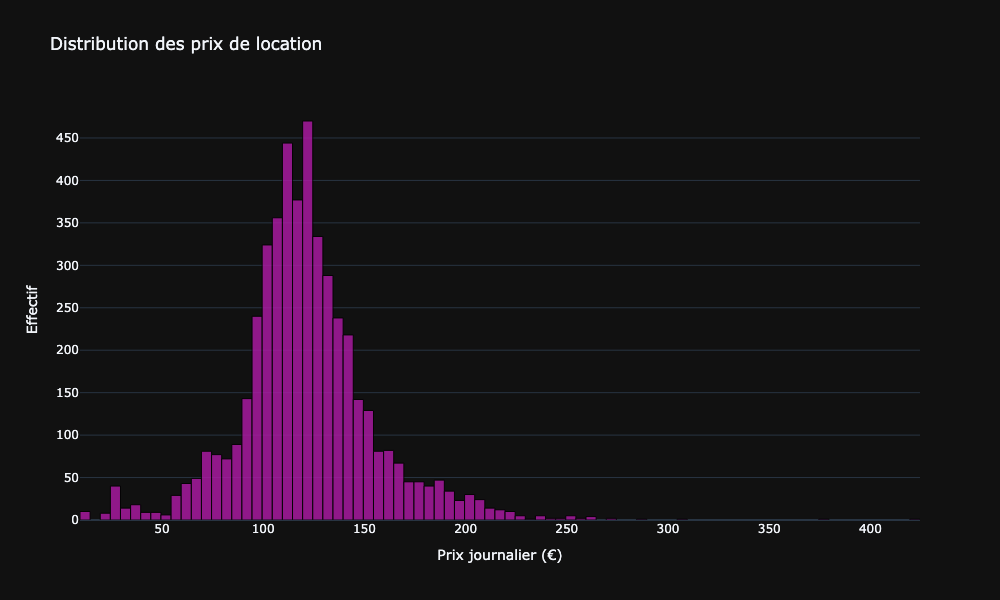

In [135]:
fig = px.histogram(
    prices,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Distribution des prix de location",
)
fig.update_traces(marker_line_color="black", marker_line_width=1, opacity=0.8)
fig.update_xaxes(title="Prix journalier (€)")
fig.update_yaxes(title="Effectif")
fig.update_layout(height=600, width=1000, showlegend=False)
fig_name = "Distribution des prix de location"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Observation sur la distribution des prix journaliers :

Distribution unimodale, centrée autour de 115-120€ (médiane 119, moyenne 121), avec un pic marqué :
les bins les plus peuplés rassemblent ~430 véhicules chacun entre 105 et 125€.
La forme est plutôt en cloche, mais asymétrique à droite (skewness 0,62) :
la queue gauche tombe rapidement vers le minimum à 10€, tandis que la queue droite s'étire longuement jusqu'à 422€,
avec quelques valeurs extrêmes très isolées.
L'étalement central reste modéré (écart-type ≈ 34€, IQR = 32€), ce qui donne une distribution plus pointue qu'une gaussienne,
fortement concentrée autour du mode mais ponctuée d'un segment premium minoritaire et bien visible.

Figure 14_Prix_journaliers_medians_par_marque exportée vers ../images/14_Prix_journaliers_medians_par_marque.png


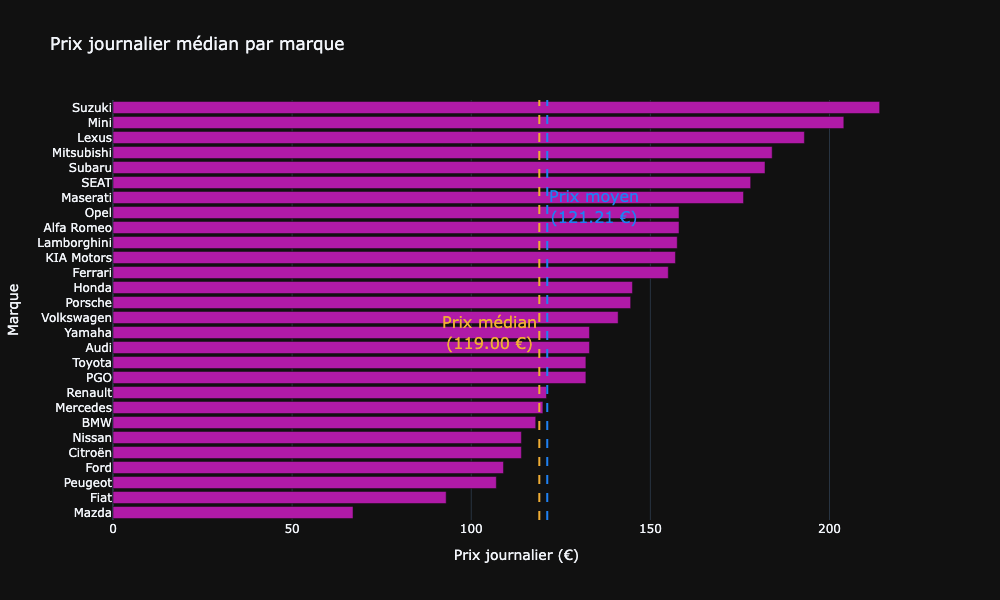

In [136]:
fig = px.bar(
    pricing.groupby('model_key')[TARGET_VAR].median().sort_values(ascending=False).reset_index(),
    x=TARGET_VAR,
    y="model_key",
    color="model_key",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Prix journalier médian par marque"
)

fig.add_vline(
    x=median_price,
    line_dash="dash",
    line_color=GETAROUND_COLORS["warning"],
    annotation=dict(text=f"Prix médian<br>({median_price:.2f} €)",  yref="paper", y=0.5, xanchor="right",
                    font=dict(size=16, color=GETAROUND_COLORS["warning"])),
)

fig.add_vline(
    x=mean_price,
    line_dash="dash",
    line_color=GETAROUND_COLORS["info"],
    annotation=dict(text=f"Prix moyen<br>({mean_price:.2f} €)", yref="paper", y=0.8, xanchor="left",
                    font=dict(size=16, color=GETAROUND_COLORS["info"])),
)

fig.update_xaxes(title="Prix journalier (€)")
fig.update_yaxes(title="Marque")
fig.update_layout(height=600, width=1000, showlegend=False)
fig_name = "Prix journaliers medians par marque"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Les prix journaliers médians par marque peuvent varier globalement du simple au double (de ~100€ à ~200€).

Nombre de marques présentes dans le dataset : 28

Figure 15_Proportion_de_vehicules_par_marque exportée vers ../images/15_Proportion_de_vehicules_par_marque.png


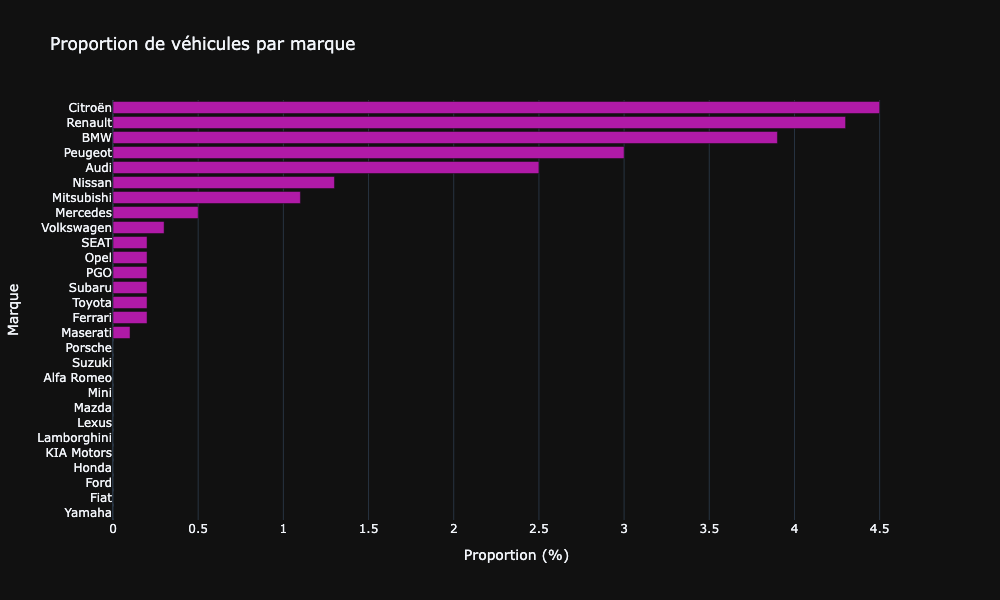

In [137]:
print(f"Nombre de marques présentes dans le dataset : {pricing['model_key'].nunique()}\n")
nb_cars_per_brand = (
    pricing
    .groupby('model_key')
    .size()
    .div(nb_rows)
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: "Proportion (%)"})
)

mean_nb_cars_per_brand = prices.mean()
median_nb_cars_per_brand = prices.median()

fig = px.bar(
    nb_cars_per_brand,
    x="Proportion (%)",
    y="model_key",
    color="model_key",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Proportion de véhicules par marque"
)

fig.update_yaxes(title="Marque")
fig.update_layout(height=600, width=1000, showlegend=False)
fig_name = "Proportion de vehicules par marque"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Il existe une forte disparité entre les 28 marques de voiture représentées dans le dataset.
En effet, cinq marques concentrent 80% du parc : 20% pour Citroën, 18,9% pour Renault, 17,1% pour BMW, 13,3% pour Peugeot et 10,9% pour Audi.
A l'inverse, 18 marques ont une part individuelle inférieure à 1%.

Figure 16_Prix_journaliers_median_par_energie exportée vers ../images/16_Prix_journaliers_median_par_energie.png


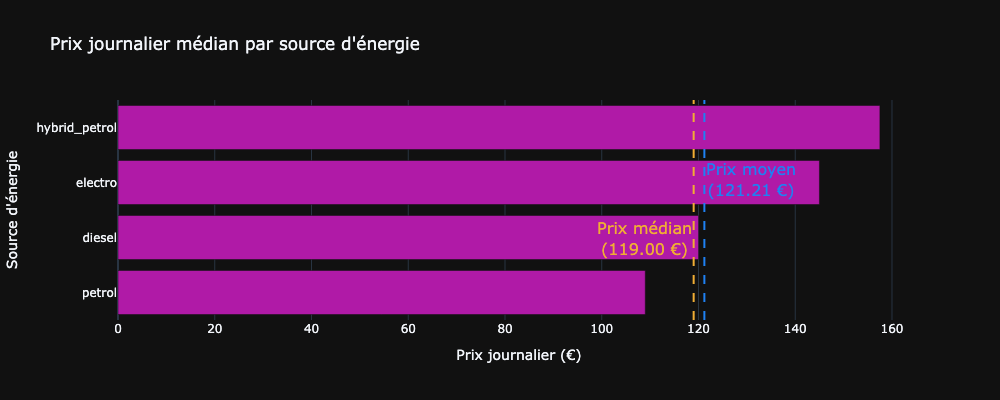

In [138]:
median_price_per_fuel_type = (
    pricing
    .groupby('fuel')
    [TARGET_VAR]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    median_price_per_fuel_type,
    x=TARGET_VAR,
    y="fuel",
    color="fuel",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Prix journalier médian par source d'énergie"
)

fig.add_vline(
    x=median_price,
    line_dash="dash",
    line_color=GETAROUND_COLORS["warning"],
    annotation=dict(text=f"Prix médian<br>({median_price:.2f} €)",  yref="paper", y=0.475, xanchor="right",
                    font=dict(size=16, color=GETAROUND_COLORS["warning"])),
)

fig.add_vline(
    x=mean_price,
    line_dash="dash",
    line_color=GETAROUND_COLORS["info"],
    annotation=dict(text=f"Prix moyen<br>({mean_price:.2f} €)", yref="paper", y=0.74, xanchor="left",
                    font=dict(size=16, color=GETAROUND_COLORS["info"])),
)

fig.update_xaxes(title="Prix journalier (€)")
fig.update_yaxes(title="Source d'énergie")
fig.update_layout(height=400, width=1000, showlegend=False)
fig_name = "Prix journaliers median par energie"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Les voitures avec une source d'énergie partiellement (hybrides) ou entièrement électrique sont celles qui ont un prix journalier plus élevé.

Figure 17_Distribution_des_prix_journaliers_par_type_de_voiture exportée vers ../images/17_Distribution_des_prix_journaliers_par_type_de_voiture.png


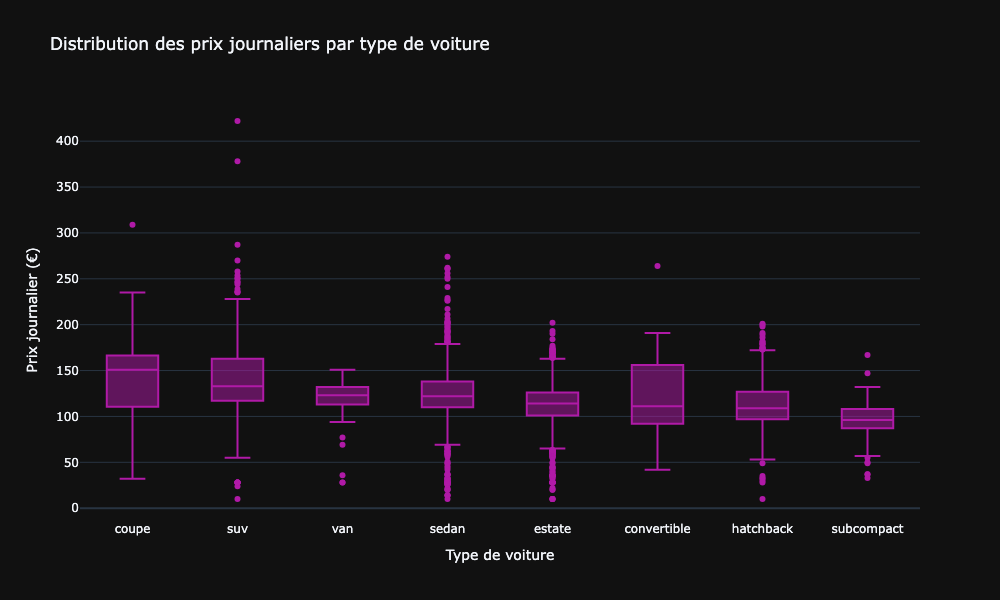

In [139]:
category_order = (
    pricing
    .groupby('car_type')
    [TARGET_VAR]
    .median()
    .reset_index()
    .sort_values(by=TARGET_VAR, ascending=False)
    ["car_type"]
)
fig = px.box(
    pricing,
    x="car_type",
    y=TARGET_VAR,
    category_orders={"car_type": category_order},
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Distribution des prix journaliers par type de voiture"
)
fig.update_xaxes(title="Type de voiture")
fig.update_yaxes(title="Prix journalier (€)")
fig.update_layout(height=600, width=1000, showlegend=False)
fig_name = "Distribution des prix journaliers par type de voiture"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Nous notons une dépendance du prix journalier au type de voiture.
En comparant les prix médians, il existe un facteur 1,57 entre les coupés (151 €) et les petites citadines (96 €).
Par ailleurs, les distributions intra-type sont inégales.
Ainsi, l'écart interquartile (IQR) des cabriolets ("convertible") est de 64 € alors que celui des vans est de 19 €.

Figure 18_Distribution_des_prix_en_fonction_des_variables_booléennes exportée vers ../images/18_Distribution_des_prix_en_fonction_des_variables_booléennes.png


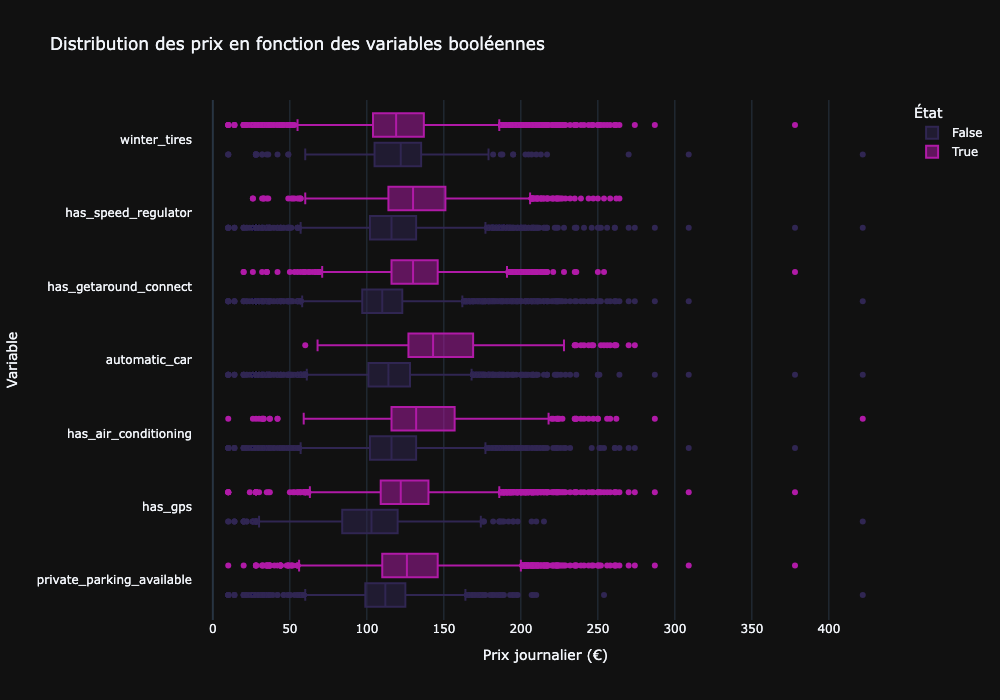

In [140]:
fig = px.box(
    pricing[bool_cols + [TARGET_VAR]].melt(
        id_vars=TARGET_VAR,
        value_vars=bool_cols,
        var_name="Variable",
        value_name="État",
    ),
    x=TARGET_VAR,
    y="Variable",
    category_orders={"État": [False, True]},
    color="État",
    orientation="h",
    color_discrete_map={True: DEFAULT_COLOR, False: ALT_COLOR},
    title="Distribution des prix en fonction des variables booléennes"
)
fig.update_xaxes(title="Prix journalier (€)")
fig.update_layout(
    height=100*7,
    width=1000,
    boxgap=0.2,        # espace entre les lignes (0 = collé, 1 = box invisibles), défaut 0.3
    boxgroupgap=0.2,   # espace entre True et False sur une même ligne, défaut 0.3
)
fig_name = "Distribution des prix en fonction des variables booléennes"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Pour les six équipements ou options définis par les variables booléennes, nous pouvons noter que les prix sont
plus élevés quand l'option est disponible, à l'exception des pneus hiver pour lesquels la distribution des prix
est similaire dans les cas avec/sans.

En se basant sur la différence de prix journalier médian (prix avec option - prix sans option), la hiérarchie des options, de la plus à la moins chère, est :

| Option                      | Impact sur le prix journalier (€) |
|-----------------------------|-----------------------------------|
| boîte automatique           | 29                                |
| connect                     | 20                                |
| GPS                         | 19                                |
| climatisation               | 16                                |
| régulateur de vitesse       | 14                                |
| place de parking disponible | 14                                |
| pneus hiver                 | -3                                |

Ce classement est purement indicatif car il ne tient pas compte des effets combinés des options.

Figure 19_Prix_journaliers_en_fonction_de_la_puissance_moteur_et_du_kilometrage exportée vers ../images/19_Prix_journaliers_en_fonction_de_la_puissance_moteur_et_du_kilometrage.png


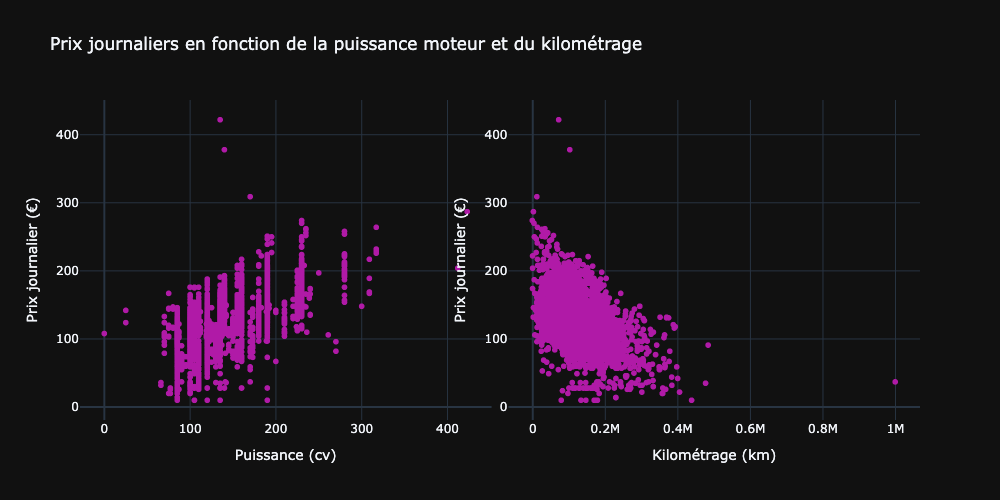

In [141]:
fig = px.scatter(
    pricing[["engine_power", "mileage", TARGET_VAR]].melt(
        id_vars=TARGET_VAR,
        value_vars=["engine_power", "mileage"],
        var_name="Variable",
        value_name="Value",
    ),
    x='Value',
    y=TARGET_VAR,
    facet_col="Variable",
    color_discrete_sequence=[DEFAULT_COLOR],
    title='Prix journaliers en fonction de la puissance moteur et du kilométrage',
)
fig.update_xaxes(matches=None, showticklabels=True)
fig.update_yaxes(matches=None, showticklabels=True, title_text="Prix journalier (€)")
fig.update_xaxes(title_text="Puissance (cv)", col=1)
fig.update_xaxes(title_text="Kilométrage (km)", col=2)
mapping = {
    "fuel=diesel": "Diesel",
    "fuel=petrol": "Essence",
}
fig.for_each_annotation(lambda a: a.update(text=""))
fig_name = "Prix journaliers en fonction de la puissance moteur et du kilometrage"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Le nuage de points donnant les prix journaliers en fonction de la puissance moteur nous montre la corrélation assez forte et
positive entre les deux variables.
L'autre nuage de points entre le prix et le kilométrage indique une corrélation modérée et négative.
Les valeurs numériques sont calculés plus bas.

Nombre de colonnes après encodage des colonnes catégorielles : 60

Figure 20_Top_20_variables_plus_correlees_avec_prix_journalier exportée vers ../images/20_Top_20_variables_plus_correlees_avec_prix_journalier.png


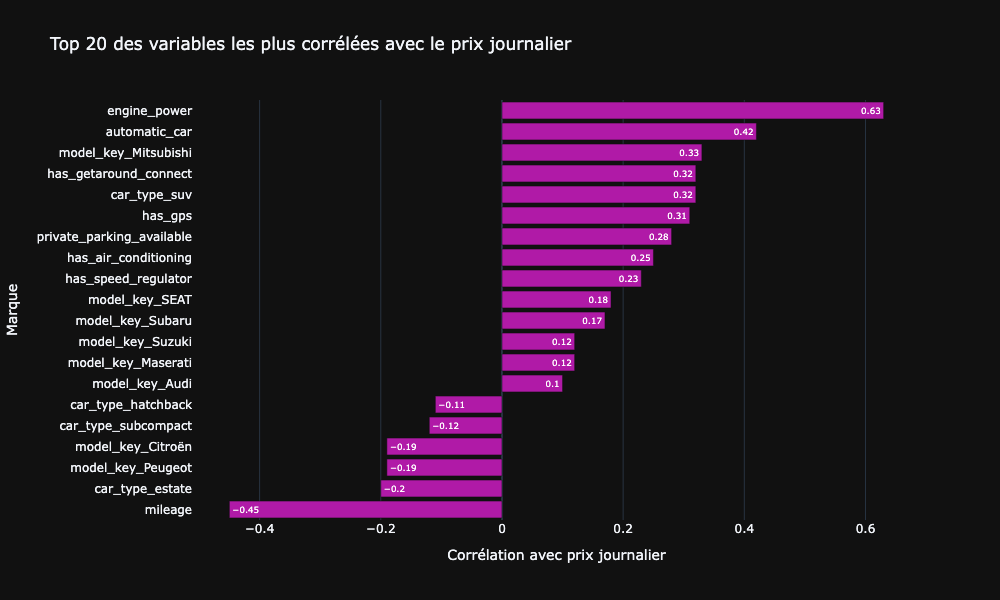

In [142]:
pricing_with_encoded_cat_cols = pd.get_dummies(pricing, columns=cat_cols, drop_first=False)
corr = pricing_with_encoded_cat_cols.corr()
sorted_correlated_features = (
    corr
    .abs()
    [TARGET_VAR]
    .drop(TARGET_VAR)
    .sort_values(ascending=False)

)
top20_var_names = sorted_correlated_features.index[:20]
top20_vars = (
    corr
    .loc[top20_var_names, :]
    [TARGET_VAR]
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
    .rename(
        columns={
            "index": "Variable",
            "rental_price_per_day": "Corrélation avec prix journalier"
        }
    )
)
print(
    "Nombre de colonnes après encodage des colonnes catégorielles : " +
    f"{pricing_with_encoded_cat_cols.shape[1]}\n"
)

fig = px.bar(
    top20_vars,
    x="Corrélation avec prix journalier",
    y="Variable",
    color="Variable",
    text_auto=True,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Top 20 des variables les plus corrélées avec le prix journalier"
)
fig.update_yaxes(title="Marque")
fig.update_layout(height=600, width=1000, showlegend=False)
fig_name = "Top 20 variables plus correlees avec prix journalier"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Observations sur les corrélations avec le prix journalier :
- `engine_power` (0,63) : variable la plus positivement corrélée, également en valeur absolue.
La puissance est un proxy de supériorité de gamme.
- `mileage` (-0,45) : variable la plus négativement corrélée, également en valeur absolue.
Le kilométrage est un indicateur d'ancienneté.
- Certaines marques de voiture sont modérément à faiblement corrélées au prix : Mitsubishi (+0,33), Peugeot et Citroën (~-0,19), Seat et Subaru (~+0,17), Suzuki, Maserati et Audi (~0,10 à ~+0,12). Les autres marques sont (très) faiblement corrélés (<0,10 en valeur absolu).
- `automatic_car` (+0,42) : troisième variable la plus fortement corrélée et première parmi les équipements. Viennent ensuite : l'installation de connect (+0,32), d'un navigateur GPS (+0,31), d'une climatisation (+0,25) et d'un régulateur de vitesse (+0,23).
- Le type de voiture le plus fortement corrélé au prix journalier est le SUV (+0,32). Ensuite suivent le break ("estate", -0,2), la petite citadine ("subcompact", -0,12) et la citadine classique ("hatchback", -0,11). Les autres types sont (très) faiblement corrélés (<0,10 en valeur absolu).
- `private_parking_available` (+0,28) : niveau de corrélation similaire aux équipements cités ci-avant.
- Absent de ce top 20 : la motorisation / source d'énergie ("fuel"), la couleur de la carrosserie, l'installation de pneus hiver, les autres marques et les 4 autres types de voiture (cabriolet - "convertible", berline - "sedan", "van", coupé).

Cette EDA a fait émerger plusieurs déterminants candidats pour la modélisation du prix journalier :

- une cible asymétrique à droite (médiane 119€, skewness 0,62, queue jusqu'à 422€), à surveiller pour le choix de la métrique et une éventuelle transformation
- la marque comme variable catégorielle structurante mais très déséquilibrée (5 marques sur 28 concentrent 80% du parc), donc à encoder avec précaution
- le type de voiture et le type d'énergie, tous deux nettement discriminants (facteur 1,57 entre coupés et citadines, premium électrique/hybride)
- six options booléennes au signal cohérent (boîte automatique, Connect, GPS, climatisation, régulateur, parking), une seule sans effet apparent (pneus hiver)
- deux variables numériques aux comportements opposés : corrélation positive forte avec la puissance moteur, négative et modérée avec le kilométrage

Ces effets, observés individuellement, restent insuffisants pour quantifier les interactions et redondances entre variables (par exemple type de voiture × motorisation, ou combinaisons d'options). La partie suivante prend donc le relais avec une approche de machine learning supervisée, dont l'objectif sera de modéliser conjointement ces facteurs pour prédire le prix journalier et alimenter l'endpoint `/predict` de l'API.

---

## Partie 7 - Pipeline ML

Cette partie met en place tout ce qui sera utilisé par les modèles des parties suivantes : nettoyage des aberrations, séparation train/validation/test, préprocesseur scikit-learn, fonctions utilitaires d'évaluation et helper de logging MLflow.

### Configuration du tracking MLflow

Le serveur MLflow est hébergé sur Hugging Face Space (backend Neon PostgreSQL, artifacts sur S3). L'URI et les credentials sont fournis via variables d'environnement ("MLFLOW_TRACKING_URI", "MLFLOW_TRACKING_USERNAME", "MLFLOW_TRACKING_PASSWORD", "AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY").

In [48]:
EXPERIMENT_NAME = "getaround-pricing"

load_dotenv()

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)

2026/06/12 13:21:38 INFO mlflow.tracking.fluent: Experiment with name 'getaround-pricing' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://getaround-project-yoannrobert-698428315790-eu-west-3-an/mlflow_artifacts/1', creation_time=1781263298430, experiment_id='1', last_update_time=1781263298430, lifecycle_stage='active', name='getaround-pricing', tags={}, trace_location=None, workspace='default'>

### Constantes et listes de colonnes

In [49]:
RANDOM_STATE = 42
TARGET_VAR = "rental_price_per_day"

num_cols = ["mileage", "engine_power"]
cat_cols = ["model_key", "fuel", "paint_color", "car_type"]
bool_cols = [
    "private_parking_available",
    "has_gps",
    "has_air_conditioning",
    "automatic_car",
    "has_getaround_connect",
    "has_speed_regulator",
    "winter_tires",
]
feature_cols = num_cols + cat_cols + bool_cols

### Nettoyage des aberrations

Trois étapes successives :
1. suppression des aberrations logiques (kilométrage négatif, puissance ou prix non strictement positifs)
2. filtrage IQR (règle 1,5 x IQR) sur les variables numériques pour écarter les valeurs extrêmes
3. regroupement dans une catégorie "Other" des marques représentant moins de 1% du dataset, pour limiter l'explosion dimensionnelle après one-hot encoding

In [61]:
# Aberrations logiques
n_before = len(pricing)
data = pricing[
    (pricing["mileage"] >= 0)
    & (pricing["engine_power"] > 0)
    & (pricing[TARGET_VAR] > 0)
].copy()
print(f"Aberrations logiques : {n_before - len(data)} lignes supprimées")

Aberrations logiques : 2 lignes supprimées


In [62]:
# # Filtrage IQR sur les variables numériques
# for col in num_cols:
#     q1 = data[col].quantile(0.25)
#     q3 = data[col].quantile(0.75)
#     iqr = q3 - q1
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
#     n_before = len(data)
#     data = data[(data[col] >= lower) & (data[col] <= upper)]
#     print(f"IQR sur {col} : {n_before - len(data)} lignes supprimées")

In [63]:
# Regroupement des marques rares
brand_freq = data["model_key"].value_counts(normalize=True)
rare_brands = brand_freq[brand_freq < 0.01].index.tolist()
data["model_key"] = data["model_key"].where(
    ~data["model_key"].isin(rare_brands), "Other"
)
print(f"Marques regroupées dans 'Other' : {len(rare_brands)}")
print(f"Marques restantes : {data['model_key'].nunique()}")
print(f"Taille finale du dataset : {len(data)} lignes")

Marques regroupées dans 'Other' : 18
Marques restantes : 11
Taille finale du dataset : 4841 lignes


### Séparation train / validation / test

Avec ~4800 lignes, un split **70/15/15** offre le meilleur compromis : suffisamment de données d'entraînement pour les modèles non linéaires (Random Forest, XGBoost) et des splits de validation et test assez grands (~700 lignes chacun) pour des estimations de métriques fiables.

In [64]:
X = data[feature_cols]
y = data[TARGET_VAR]

# Split en 70% train / 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
# Découpe du 30% restant en 15% validation / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Train      : {len(X_train):>4} ({len(X_train) / len(X):.1%})")
print(f"Validation : {len(X_val):>4} ({len(X_val) / len(X):.1%})")
print(f"Test       : {len(X_test):>4} ({len(X_test) / len(X):.1%})")

Train      : 3388 (70.0%)
Validation :  726 (15.0%)
Test       :  727 (15.0%)


### Préprocesseur

Un `ColumnTransformer` combine :
- `StandardScaler` sur les variables numériques (utile pour la régression linéaire, inoffensif pour les modèles à base d'arbres)
- `OneHotEncoder` sur les variables catégorielles, avec `handle_unknown="ignore"` pour rester robuste à d'éventuelles modalités inconnues en production
- passthrough sur les variables booléennes

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough",
)

### Fonctions utilitaires

Deux fonctions réutilisées dans les parties suivantes :
- `compute_metrics` retourne un dictionnaire MAE / RMSE / R²
- `log_model_run` encapsule la création d'un run MLflow avec paramètres, métriques train/validation, signature et exemple d'input

In [66]:
def compute_metrics(y_true, y_pred):
    """Retourne MAE, RMSE et R² sous forme de dictionnaire."""
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }

In [67]:
def log_model_run(
    model,
    run_name,
    params,
    metrics_train,
    metrics_val,
    X_sample,
):
    """Log un run MLflow : paramètres, métriques et modèle scikit-learn."""
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        for name, value in metrics_train.items():
            mlflow.log_metric(f"train_{name}", value)
        for name, value in metrics_val.items():
            mlflow.log_metric(f"val_{name}", value)

        signature = infer_signature(X_sample, model.predict(X_sample))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=X_sample.head(3),
        )
        return run.info.run_id

---

## Partie 8 - Développement de modèles

Trois modèles sont entraînés, chacun encapsulé dans un `Pipeline` scikit-learn associant le préprocesseur défini en partie 7 à un estimateur :
- une **régression linéaire** comme baseline
- une **forêt aléatoire** (`RandomForestRegressor`)
- **XGBoost** (`XGBRegressor`)

Chaque modèle utilise ses hyperparamètres par défaut. L'optimisation sera abordée en partie 10 sur le meilleur candidat.

### Baseline : régression linéaire

In [69]:
lr_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)
lr_pipeline.fit(X_train, y_train)

lr_train_metrics = compute_metrics(y_train, lr_pipeline.predict(X_train))
lr_val_metrics = compute_metrics(y_val, lr_pipeline.predict(X_val))

log_model_run(
    model=lr_pipeline,
    run_name="LinearRegression",
    params={"model_type": "LinearRegression"},
    metrics_train=lr_train_metrics,
    metrics_val=lr_val_metrics,
    X_sample=X_train,
)

print(
    f"Validation - "
    f"MAE: {lr_val_metrics['mae']:.2f} € | "
    f"RMSE: {lr_val_metrics['rmse']:.2f} € | "
    f"R²: {lr_val_metrics['r2']:.3f}"
)

/Users/yrobert/Programs/miniconda3/envs/getaround/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 13:44:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:45:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle fo

🏃 View run LinearRegression at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1/runs/565486ee617640e8afbf9f65736e72b8
🧪 View experiment at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1
Validation - MAE: 12.28 € | RMSE: 18.32 € | R²: 0.693


### Random Forest

In [70]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)
rf_pipeline.fit(X_train, y_train)

rf_train_metrics = compute_metrics(y_train, rf_pipeline.predict(X_train))
rf_val_metrics = compute_metrics(y_val, rf_pipeline.predict(X_val))

log_model_run(
    model=rf_pipeline,
    run_name="RandomForest",
    params={
        "model_type": "RandomForestRegressor",
        "random_state": RANDOM_STATE,
    },
    metrics_train=rf_train_metrics,
    metrics_val=rf_val_metrics,
    X_sample=X_train,
)

print(
    f"Validation - "
    f"MAE: {rf_val_metrics['mae']:.2f} € | "
    f"RMSE: {rf_val_metrics['rmse']:.2f} € | "
    f"R²: {rf_val_metrics['r2']:.3f}"
)

/Users/yrobert/Programs/miniconda3/envs/getaround/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 13:46:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:46:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle fo

🏃 View run RandomForest at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1/runs/0edaa9a71ebd4955afaf9a2ec1f3bab8
🧪 View experiment at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1
Validation - MAE: 11.10 € | RMSE: 17.65 € | R²: 0.715


### XGBoost

In [71]:
xgb_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)
xgb_pipeline.fit(X_train, y_train)

xgb_train_metrics = compute_metrics(y_train, xgb_pipeline.predict(X_train))
xgb_val_metrics = compute_metrics(y_val, xgb_pipeline.predict(X_val))

log_model_run(
    model=xgb_pipeline,
    run_name="XGBoost",
    params={
        "model_type": "XGBRegressor",
        "random_state": RANDOM_STATE,
    },
    metrics_train=xgb_train_metrics,
    metrics_val=xgb_val_metrics,
    X_sample=X_train,
)

print(
    f"Validation - "
    f"MAE: {xgb_val_metrics['mae']:.2f} € | "
    f"RMSE: {xgb_val_metrics['rmse']:.2f} € | "
    f"R²: {xgb_val_metrics['r2']:.3f}"
)

/Users/yrobert/Programs/miniconda3/envs/getaround/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 13:47:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:47:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle fo

🏃 View run XGBoost at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1/runs/f3061a08706d4979bab48c099fa249a4
🧪 View experiment at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1
Validation - MAE: 10.67 € | RMSE: 16.92 € | R²: 0.738


---

## Partie 9 - Comparaison et sélection

Les métriques calculées en partie 8 sont consolidées dans un tableau unique, puis le meilleur candidat est sélectionné sur la base de la RMSE de validation. Ce candidat sera optimisé en partie 10.

### Tableau comparatif

In [72]:
models_summary = {
    "LinearRegression": {
        "train": lr_train_metrics,
        "val": lr_val_metrics,
        "pipeline": lr_pipeline,
    },
    "RandomForest": {
        "train": rf_train_metrics,
        "val": rf_val_metrics,
        "pipeline": rf_pipeline,
    },
    "XGBoost": {
        "train": xgb_train_metrics,
        "val": xgb_val_metrics,
        "pipeline": xgb_pipeline,
    },
}

results = pd.DataFrame(
    {
        name: {
            **{f"train_{k}": v for k, v in d["train"].items()},
            **{f"val_{k}": v for k, v in d["val"].items()},
        }
        for name, d in models_summary.items()
    }
).T.round(3)
results

,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2
LinearRegression,12.214,18.442,0.700,12.275,18.324,0.693
RandomForest,3.933,6.317,0.965,11.104,17.645,0.715
XGBoost,4.575,6.595,0.962,10.666,16.919,0.738


### Sélection du meilleur modèle

Le critère retenu est la **RMSE sur le set de validation** : elle pénalise plus fortement les grosses erreurs, ce qui est pertinent sur une cible asymétrique avec une queue premium. L'écart `train` vs `val` permet en parallèle de juger du niveau de surapprentissage.

In [73]:
best_model_name = results["val_rmse"].idxmin()
best_pipeline = models_summary[best_model_name]["pipeline"]

print(f"Meilleur modèle (RMSE validation) : {best_model_name}")
print(
    f"  MAE val  : {results.loc[best_model_name, 'val_mae']:.2f} €\n"
    f"  RMSE val : {results.loc[best_model_name, 'val_rmse']:.2f} €\n"
    f"  R² val   : {results.loc[best_model_name, 'val_r2']:.3f}"
)

Meilleur modèle (RMSE validation) : XGBoost
  MAE val  : 10.67 €
  RMSE val : 16.92 €
  R² val   : 0.738


**XGBoost est retenu comme candidat à optimiser.** Il domine les trois métriques de validation : MAE 10,67€ (vs 11,10€ pour Random Forest et 12,28€ pour la baseline), RMSE 16,92€ et R² 0,738. L'écart avec Random Forest reste modéré (~0,7€ sur MAE et RMSE) mais systématique.

Deux observations méthodologiques accompagnent ce choix :

- la régression linéaire affiche des performances `train` et `val` quasi identiques (R² 0,700 vs 0,693), ce qui confirme l'absence de surapprentissage mais aussi un plafond de capacité atteint sur ces variables.
- les deux modèles à arbres présentent à l'inverse un fort surapprentissage (R² train ≈ 0,96 vs val ≈ 0,72-0,74, RMSE multipliée par ~2,7 entre les deux splits). Cet écart laisse une marge confortable d'amélioration via la régularisation et la limitation de la complexité des arbres, ce qui sera précisément l'objet du tuning en partie 10.

---

## Partie 10 - Optimisation des hyperparamètres

XGBoost est optimisé via `RandomizedSearchCV` (5 folds, scoring `neg_root_mean_squared_error` pour rester cohérent avec le critère de sélection de la partie 9).

La grille cible spécifiquement la réduction du surapprentissage observé en partie 8 (R² train 0,96 vs R² val 0,74) via les paramètres de complexité (`max_depth`, `min_child_weight`), d'échantillonnage stochastique (`subsample`, `colsample_bytree`) et de régularisation (`reg_alpha`, `reg_lambda`).

### Grille de recherche

In [77]:
N_ITER = 30
CV_FOLDS = 5
SCORING = "neg_root_mean_squared_error"

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

### Recherche aléatoire

In [78]:
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring=SCORING,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f"Meilleur score CV (RMSE) : {-search.best_score_:.2f} €")
print("Meilleurs hyperparamètres :")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleur score CV (RMSE) : 16.19 €
Meilleurs hyperparamètres :
  subsample: 0.9
  reg_lambda: 0.5
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.05
  colsample_bytree: 0.6


### Évaluation du modèle optimisé

In [79]:
tuned_pipeline = search.best_estimator_

tuned_train_metrics = compute_metrics(y_train, tuned_pipeline.predict(X_train))
tuned_val_metrics = compute_metrics(y_val, tuned_pipeline.predict(X_val))

# Comparaison XGBoost par défaut vs XGBoost tuné
comparison_tuning = pd.DataFrame(
    {
        "XGBoost (défaut)": {
            **{f"train_{k}": v for k, v in xgb_train_metrics.items()},
            **{f"val_{k}": v for k, v in xgb_val_metrics.items()},
        },
        "XGBoost (tuné)": {
            **{f"train_{k}": v for k, v in tuned_train_metrics.items()},
            **{f"val_{k}": v for k, v in tuned_val_metrics.items()},
        },
    }
).T.round(3)
comparison_tuning

,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2
XGBoost (défaut),4.575,6.595,0.962,10.666,16.919,0.738
XGBoost (tuné),5.141,7.704,0.948,10.477,16.805,0.742


In [81]:
print(comparison_tuning.to_string())

                  train_mae  train_rmse  train_r2  val_mae  val_rmse  val_r2
XGBoost (défaut)      4.575       6.595     0.962   10.666    16.919   0.738
XGBoost (tuné)        5.141       7.704     0.948   10.477    16.805   0.742


In [80]:
# Logging du modèle tuné dans MLflow
tuning_params = {
    "model_type": "XGBRegressor",
    "tuning": "RandomizedSearchCV",
    "n_iter": N_ITER,
    "cv_folds": CV_FOLDS,
    "scoring": SCORING,
    **{k.replace("model__", ""): v for k, v in search.best_params_.items()},
}

log_model_run(
    model=tuned_pipeline,
    run_name="XGBoost_tuned",
    params=tuning_params,
    metrics_train=tuned_train_metrics,
    metrics_val=tuned_val_metrics,
    X_sample=X_train,
)

/Users/yrobert/Programs/miniconda3/envs/getaround/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 14:02:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 14:02:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle fo

🏃 View run XGBoost_tuned at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1/runs/7bb7282975b64c43b80e157af5a9f466
🧪 View experiment at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1


'7bb7282975b64c43b80e157af5a9f466'

L'optimisation apporte un gain marginal, mais cohérent : **MAE de validation passe de 10,67€ à 10,48€** (-0,19€), RMSE de 16,92€ à 16,80€ (-0,11€), R² de 0,738 à 0,742. Le modèle gagne environ 2% en précision moyenne.

L'effet sur le surapprentissage est plus net que sur la performance brute : R² train recule de 0,962 à 0,948 et MAE train remonte de 4,58€ à 5,14€, signe que la régularisation a freiné la sur-spécialisation sur les données d'entraînement. L'écart `train` vs `val` reste cependant marqué (MAE 5,14€ vs 10,48€), suggérant qu'on touche probablement à la limite du signal exploitable par ce jeu de variables.

Le modèle tuné est retenu pour l'évaluation finale sur le test set en partie 11.

---

## Partie 11 - Évaluation finale et sauvegarde

Étapes :
1. réentrainement du modèle tuné sur `train + validation` pour exploiter le maximum de données disponibles
2. évaluation finale sur le **test set**, jamais vu jusqu'ici
3. enregistrement dans le **MLflow Model Registry** avec signature et exemple d'input, puis promotion via l'alias `production`
4. test de chargement du modèle depuis le registre pour valider son utilisation future par l'API

### Réentrainement sur train + validation

In [83]:
# Clone du pipeline tuné (récupère les hyperparamètres sans l'état appris)
final_pipeline = clone(tuned_pipeline)

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_pipeline.fit(X_trainval, y_trainval)

print(f"Réentrainement sur {len(X_trainval)} lignes (train + validation)")

Réentrainement sur 4114 lignes (train + validation)


### Évaluation sur le test set

In [84]:
final_trainval_metrics = compute_metrics(
    y_trainval, final_pipeline.predict(X_trainval)
)
final_test_metrics = compute_metrics(
    y_test, final_pipeline.predict(X_test)
)

final_comparison = pd.DataFrame(
    {
        "validation (tuné)": tuned_val_metrics,
        "test (final)": final_test_metrics,
    }
).T.round(3)
final_comparison

,mae,rmse,r2
validation (tuné),10.477,16.805,0.742
test (final),10.296,15.126,0.790


### Visualisation des performances

Figure 21_Prix_predits_vs_prix_reels exportée vers ../images/21_Prix_predits_vs_prix_reels.png


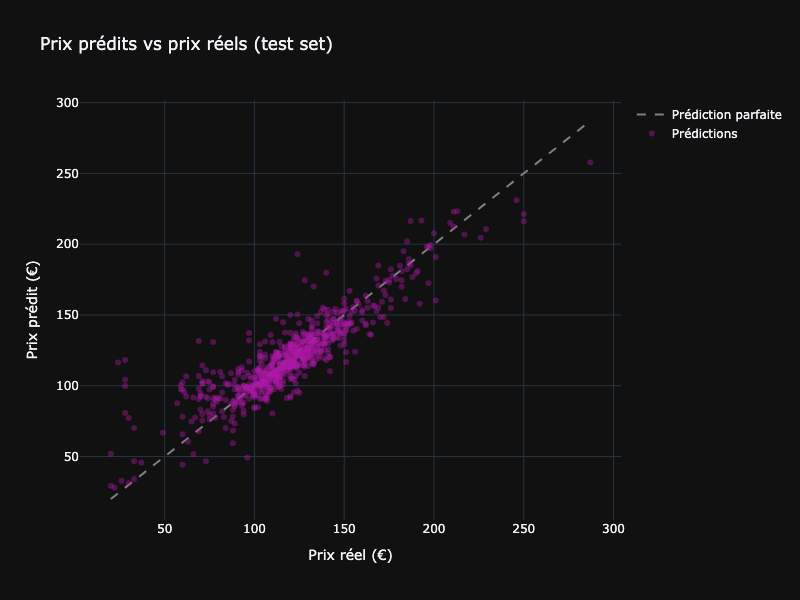

In [143]:
# Stockage des prédictions pour réutilisation dans les figures suivantes
y_test_pred = final_pipeline.predict(X_test)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode="lines",
    line=dict(color="gray", dash="dash"),
    name="Prédiction parfaite",
))
fig.add_trace(go.Scatter(
    x=y_test,
    y=y_test_pred,
    mode="markers",
    marker=dict(color=DEFAULT_COLOR, opacity=0.4, size=6),
    name="Prédictions",
))
fig.update_layout(
    title="Prix prédits vs prix réels (test set)",
    xaxis_title="Prix réel (€)",
    yaxis_title="Prix prédit (€)",
    width=800,
    height=600,
)
fig_name = "Prix predits vs prix reels"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Le nuage de points s'organise globalement autour de la ligne de prédiction
parfaite, confirmant la qualité d'ajustement signalée par le R² de 0,790. La
dispersion verticale autour de cette ligne reste néanmoins significative et
révèle l'irréductibilité d'une partie de l'erreur, déjà chiffrée par la MAE
(10,30 €). Un comportement plus marqué apparaît sur la partie basse de
l'intervalle : plusieurs véhicules à prix réel modéré sont prédits sensiblement
au-dessus de leur valeur observée. Le modèle peine donc à modéliser le bas du
segment et tend à le tirer vers la moyenne.

Figure 22_Top_20_features_importantes exportée vers ../images/22_Top_20_features_importantes.png


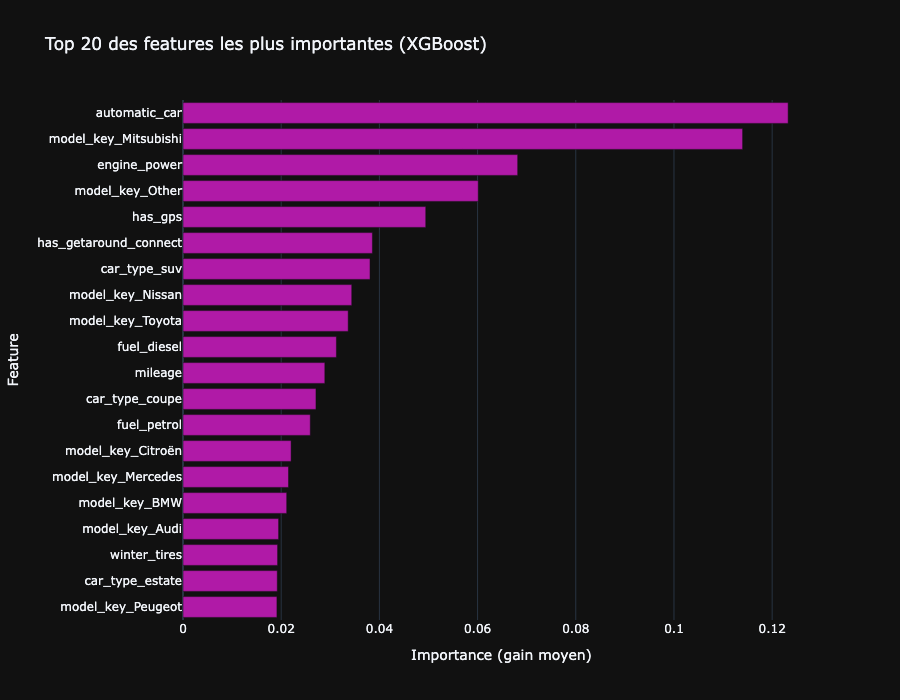

In [144]:
# Récupération des noms de features après le ColumnTransformer
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = final_pipeline.named_steps["model"].feature_importances_

# Nettoyage des préfixes ajoutés par le ColumnTransformer
cleaned_names = pd.Series(feature_names).str.replace(
    r"^(num__|cat__|remainder__)", "", regex=True
)

importance_df = (
    pd.DataFrame({"feature": cleaned_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
    .sort_values("importance", ascending=True)
)

fig = px.bar(
    importance_df,
    x="importance",
    y="feature",
    orientation="h",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Top 20 des features les plus importantes (XGBoost)",
)
fig.update_layout(
    xaxis_title="Importance (gain moyen)",
    yaxis_title="Feature",
    width=900,
    height=700,
    showlegend=False,
)
fig_name = "Top 20 features importantes"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Le classement des importances confirme et précise les déterminants identifiés
en partie 6 :

- la **boîte automatique** arrive en tête (importance 0,123), en cohérence
  directe avec l'EDA qui en faisait l'option à plus fort impact sur le prix
  médian (+29 €)
- la **puissance moteur** (`engine_power`) figure en 3ᵉ position, conformément
  à la corrélation positive forte observée précédemment
- la **marque** est massivement représentée : neuf des vingt premières features
  sont des modalités de `model_key`, traduisant la disparité tarifaire de
  l'ordre du simple au double déjà mise en évidence. La catégorie agrégée
  `Other` se classe 4ᵉ, validant a posteriori le choix de regroupement des
  marques rares
- les **options Connect et GPS** apparaissent respectivement aux 5ᵉ et 6ᵉ
  rangs, en accord avec leurs effets positifs nets sur le prix médian (+20 €
  et +19 €)
- le **type de voiture** (`suv`, `coupe`, `estate`) et le **carburant**
  (`diesel`, `petrol`) confirment leur rôle discriminant déjà observé
- la couleur (`paint_color`) est totalement absente du top 20, ce qui valide
  l'absence d'effet métier attendue

Un point notable mérite attention : les **pneus hiver** apparaissent à la
19ᵉ place malgré un effet quasi nul sur le prix médian en EDA (-3 €). Cette
contradiction apparente s'explique vraisemblablement par une interaction
captée par XGBoost (par exemple une corrélation entre cette option et
certains types de véhicules ou régions implicites), que l'analyse univariée
ne pouvait pas révéler.

Moyenne des résidus : -0.50 €
Médiane des résidus : 1.43 €
Écart-type :          15.13 €
Figure 23_Distribution_residus_sur_test_set exportée vers ../images/23_Distribution_residus_sur_test_set.png


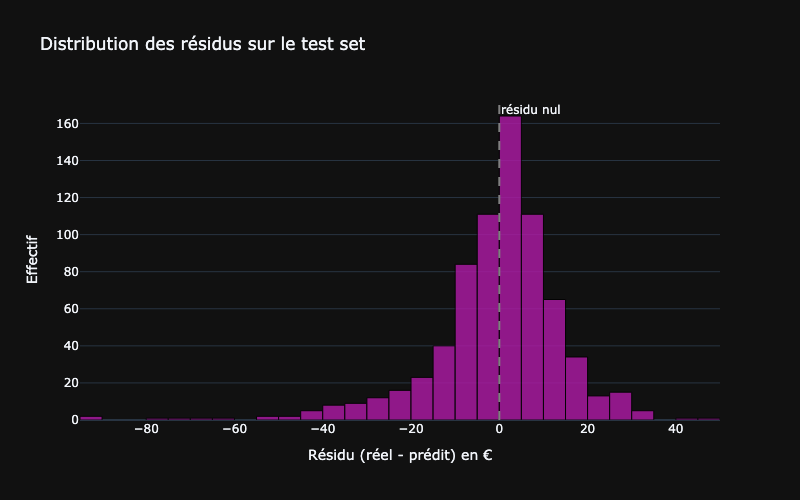

In [145]:
residuals = y_test - y_test_pred

fig = px.histogram(
    residuals,
    nbins=50,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Distribution des résidus sur le test set",
)
fig.update_traces(marker_line_color="black", marker_line_width=1, opacity=0.8)
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="gray",
    annotation_text="résidu nul",
)
fig.update_layout(
    xaxis_title="Résidu (réel - prédit) en €",
    yaxis_title="Effectif",
    width=800,
    height=500,
    showlegend=False,
)

print(
    f"Moyenne des résidus : {residuals.mean():.2f} €\n"
    f"Médiane des résidus : {residuals.median():.2f} €\n"
    f"Écart-type :          {residuals.std():.2f} €"
)
fig_name = "Distribution residus sur test set"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

In [98]:
print(
    f"Moyenne :          {residuals.mean():>7.2f} €\n"
    f"Médiane :          {residuals.median():>7.2f} €\n"
    f"Écart-type :       {residuals.std():>7.2f} €\n"
    f"Skewness :         {residuals.skew():>7.2f}\n"
    f"Min :              {residuals.min():>7.2f} €\n"
    f"Max :              {residuals.max():>7.2f} €\n"
    f"Q1 :               {residuals.quantile(0.25):>7.2f} €\n"
    f"Q3 :               {residuals.quantile(0.75):>7.2f} €\n"
    f"IQR :              {residuals.quantile(0.75) - residuals.quantile(0.25):>7.2f} €\n"
    f"% résidus > 0 :    {(residuals > 0).mean():>7.1%}\n"
    f"% |résidu| < 10€ : {(residuals.abs() < 10).mean():>7.1%}\n"
    f"% |résidu| < 20€ : {(residuals.abs() < 20).mean():>7.1%}"
)

Moyenne :            -0.50 €
Médiane :             1.43 €
Écart-type :         15.13 €
Skewness :           -1.50
Min :               -92.42 €
Max :                46.73 €
Q1 :                 -6.35 €
Q3 :                  7.72 €
IQR :                14.07 €
% résidus > 0 :      56.3%
% |résidu| < 10€ :   64.6%
% |résidu| < 20€ :   86.9%


La distribution des résidus est centrée autour de zéro (moyenne -0,50 €,
médiane 1,43 €), ce qui exclut tout biais systématique du modèle. L'écart-type
de 15,13 € correspond exactement à la RMSE attendue, et l'IQR resserré
(14,07 €) traduit une bonne concentration des erreurs autour de la valeur
centrale.

En termes opérationnels, **64,6 % des prédictions sont à moins de 10 € de
la valeur réelle** et **86,9 % à moins de 20 €**, ce qui constitue un niveau
de précision satisfaisant au regard de la médiane des prix observés (119 €).

La distribution présente cependant une **asymétrie marquée vers la gauche**
(skewness -1,50) : la queue des résidus très négatifs est nettement plus
étendue que celle des résidus positifs (min -92 € contre max +47 €). Ce
phénomène recoupe directement l'observation faite sur la figure prix prédits
vs pris réels : les erreurs les plus importantes correspondent à des
surestimations du modèle, typiquement sur les véhicules d'entrée de gamme
dont le prix réel reste modéré.
Cette signature suggère que le modèle, entraîné sur une cible
elle-même asymétrique (skewness 0,62), peine à apprendre les véhicules les
moins coûteux, sous-représentés dans le dataset.

### Enregistrement dans le Model Registry

Le modèle est logué dans un run dédié et enregistré dans le registre sous le nom `getaround-pricing`. La signature et l'`input_example` garantissent que l'API FastAPI saura quel format d'entrée attendre.

In [86]:
REGISTERED_MODEL_NAME = "getaround-pricing"

with mlflow.start_run(run_name="XGBoost_final") as final_run:
    mlflow.log_params(tuning_params)
    for name, value in final_trainval_metrics.items():
        mlflow.log_metric(f"trainval_{name}", value)
    for name, value in final_test_metrics.items():
        mlflow.log_metric(f"test_{name}", value)

    signature = infer_signature(
        X_trainval, final_pipeline.predict(X_trainval)
    )
    model_info = mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=X_trainval.head(3),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

print(f"Modèle enregistré : {REGISTERED_MODEL_NAME}")
print(f"Run ID : {final_run.info.run_id}")

/Users/yrobert/Programs/miniconda3/envs/getaround/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 14:10:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 14:10:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle fo

🏃 View run XGBoost_final at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1/runs/47d2ee633c104dd88f3949390e97cddb
🧪 View experiment at: https://yoannrobert-mlflow-getaround.hf.space/#/experiments/1
Modèle enregistré : getaround-pricing
Run ID : 47d2ee633c104dd88f3949390e97cddb


### Promotion en production via alias

MLflow 2.9+ recommande l'utilisation d'**alias** plutôt que les stages dépréciés (`Staging`, `Production`). L'alias `production` permet à l'API de référencer le modèle via `models:/getaround-pricing@production` sans connaître le numéro de version, ce qui simplifie les mises à jour futures.

In [87]:
client = MlflowClient()

# Récupération de la dernière version enregistrée
latest_version = max(
    int(v.version)
    for v in client.search_model_versions(
        f"name='{REGISTERED_MODEL_NAME}'"
    )
)

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="production",
    version=latest_version,
)

print(f"Version {latest_version} promue avec l'alias 'production'")

Version 1 promue avec l'alias 'production'


### Vérification du chargement depuis le registre

Test de bout en bout du chemin que l'API empruntera : chargement du modèle via son URI registry, puis prédiction sur quelques exemples du test set.

In [88]:
model_uri = f"models:/{REGISTERED_MODEL_NAME}@production"
loaded_model = mlflow.pyfunc.load_model(model_uri)

sample = X_test.head(3)
predictions = loaded_model.predict(sample)

print(f"Modèle chargé depuis : {model_uri}\n")
print("Exemples de prédictions :")
for actual, predicted in zip(y_test.head(3), predictions):
    print(f"  réel: {actual:>6.2f} €  |  prédit: {predicted:>6.2f} €")

Modèle chargé depuis : models:/getaround-pricing@production

Exemples de prédictions :
  réel: 137.00 €  |  prédit: 128.51 €
  réel: 126.00 €  |  prédit: 121.63 €
  réel:  74.00 €  |  prédit:  81.90 €


---

## Partie 12 - Conclusion surs la prédiction de prix

L'EDA du dataset de pricing a identifié les principaux déterminants du prix
journalier : puissance moteur (corrélation positive forte), type de voiture
et carburant, marque (segmentée par regroupement des modalités rares), et
six options à effet positif net.

Le pipeline ML adopte une approche directe et pragmatique : nettoyage des
aberrations logiques, split 70/15/15, `ColumnTransformer` associant
`StandardScaler` et `OneHotEncoder`, et trois modèles comparés (régression
linéaire, Random Forest, XGBoost). XGBoost a dominé sur les trois métriques
de validation et a été retenu pour le tuning via `RandomizedSearchCV`.

La performance finale sur le test set est très satisfaisante :
- **MAE 10,30€**, soit environ **8,7% d'erreur relative** rapporté à la
  médiane de la cible (119€)
- **RMSE 15,13€** et **R² 0,790**, en amélioration par rapport à la
  validation (signe d'une bonne généralisation, le réentrainement sur
  `train + validation` ayant tiré parti des 727 lignes supplémentaires)
- **86,9% des prédictions à moins de 20€ de la valeur réelle** et **64,6%
  à moins de 10€**, une précision opérationnelle confortable

Les diagnostics visuels confirment la robustesse du modèle : les résidus sont
centrés sur zéro (pas de biais systématique) et les importances des features
sont en parfaite cohérence avec les déterminants identifiés en EDA. Le modèle
présente cependant une limite identifiée : il tend à surestimer le prix des
véhicules d'entrée de gamme, sous-représentés dans le dataset. Cette
faiblesse est documentée mais reste périphérique au cas d'usage principal.

Le modèle est enregistré dans le MLflow Model Registry sous le nom
`getaround-pricing` et promu via l'alias `production`. Il peut être consommé
par l'API FastAPI via `models:/getaround-pricing@production`, ce qui boucle
la chaîne EDA → modélisation → mise en production.